In [1]:
# ============================================================
# FINAL LSTM EXPERIMENT — CAPPED RUL = 125
# FD001 / 100-cycle windows / engine-level split
# ============================================================

import pandas as pd
import numpy as np
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Masking
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. LOAD DATA
# ============================================================

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(
    "../dataset/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

print("Original data:", train_df.shape)


# ============================================================
# 2. REMOVE CONSTANT SENSORS
# ============================================================

train_df = train_df.drop(
    columns=["sensor_5", "sensor_16", "sensor_18"]
)


# ============================================================
# 3. FEATURES
# ============================================================

feature_cols = [
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

print("Number of features:", len(feature_cols))


# ============================================================
# 4. CALCULATE CAPPED RUL
# ============================================================

max_cycle = train_df.groupby(
    "engine_id"
)["cycle"].transform("max")

raw_rul = max_cycle - train_df["cycle"]

# Cap RUL at 125
train_df["RUL"] = raw_rul.clip(upper=125)

print("\nRUL statistics:")
print(train_df["RUL"].describe())


# ============================================================
# 5. SPLIT BY ENGINE — NOT BY ROW
# ============================================================

engine_ids = train_df["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = train_df[
    train_df["engine_id"].isin(train_engines)
].copy()

val_data = train_df[
    train_df["engine_id"].isin(val_engines)
].copy()

print("\nTraining engines:", len(train_engines))
print("Validation engines:", len(val_engines))


# ============================================================
# 6. CREATE SLIDING-WINDOW TRAINING SEQUENCES
# ============================================================

MAX_LEN = 100


def create_training_sequences(data, features, max_len=100):

    X = []
    y = []

    for _, engine in data.groupby("engine_id"):

        engine = engine.sort_values("cycle")

        values = engine[features].values
        rul_values = engine["RUL"].values

        for i in range(len(engine)):

            start = max(0, i - max_len + 1)

            sequence = values[start:i + 1]

            # Pad shorter sequences at beginning
            if len(sequence) < max_len:

                padding = np.zeros(
                    (max_len - len(sequence), len(features))
                )

                sequence = np.vstack([
                    padding,
                    sequence
                ])

            X.append(sequence)
            y.append(rul_values[i])

    return np.array(X), np.array(y)


X_train, y_train = create_training_sequences(
    train_data,
    feature_cols,
    MAX_LEN
)

X_val, y_val = create_training_sequences(
    val_data,
    feature_cols,
    MAX_LEN
)

print("\nTraining sequences:", X_train.shape)
print("Training targets:", y_train.shape)

print("Validation sequences:", X_val.shape)
print("Validation targets:", y_val.shape)


# ============================================================
# 7. SCALE — FIT ONLY ON TRAINING DATA
# ============================================================

scaler_capped = StandardScaler()

scaler_capped.fit(
    train_data[feature_cols].values
)

X_train_scaled = scaler_capped.transform(
    X_train.reshape(-1, len(feature_cols))
).reshape(X_train.shape)

X_val_scaled = scaler_capped.transform(
    X_val.reshape(-1, len(feature_cols))
).reshape(X_val.shape)


# ============================================================
# 8. MARK PADDING
# ============================================================

X_train_scaled[X_train == 0] = -999
X_val_scaled[X_val == 0] = -999


# ============================================================
# 9. BUILD LSTM
# ============================================================

lstm_capped = Sequential([
    Masking(
        mask_value=-999,
        input_shape=(MAX_LEN, len(feature_cols))
    ),

    LSTM(64),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

lstm_capped.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("\nModel:")
lstm_capped.summary()


# ============================================================
# 10. TRAIN
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("\nTraining...")

history = lstm_capped.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


# ============================================================
# 11. TEST-LIKE VALIDATION
# ONE PREDICTION PER VALIDATION ENGINE
# ============================================================

X_val_testlike = []
y_val_true = []
val_engine_ids = []
cutoffs = []

for engine_id in val_engines:

    engine = train_df[
        train_df["engine_id"] == engine_id
    ].sort_values("cycle")

    max_cyc = engine["cycle"].max()

    # Pretend NASA stopped observing at 80% of life
    cutoff = int(0.8 * max_cyc)

    available = engine[
        engine["cycle"] <= cutoff
    ]

    values = available[feature_cols].values

    # Scale using training-only scaler
    values_scaled = scaler_capped.transform(values)

    # Take latest 100 cycles
    if len(values_scaled) >= MAX_LEN:

        sequence = values_scaled[-MAX_LEN:]

    else:

        pad_len = MAX_LEN - len(values_scaled)

        padding = np.repeat(
            values_scaled[0:1],
            pad_len,
            axis=0
        )

        sequence = np.vstack([
            padding,
            values_scaled
        ])

    X_val_testlike.append(sequence)

    # IMPORTANT:
    # True physical RUL at cutoff.
    # We do NOT cap this validation ground truth.
    true_rul = max_cyc - cutoff

    y_val_true.append(true_rul)
    val_engine_ids.append(engine_id)
    cutoffs.append(cutoff)


X_val_testlike = np.array(X_val_testlike)
y_val_true = np.array(y_val_true)


print("\nTest-like validation input:", X_val_testlike.shape)
print("Test-like validation target:", y_val_true.shape)


# ============================================================
# 12. ONE PREDICTION PER VALIDATION ENGINE
# ============================================================

y_val_pred = lstm_capped.predict(
    X_val_testlike,
    verbose=0
).flatten()


# ============================================================
# 13. VALIDATION METRICS
# ============================================================

val_mae = mean_absolute_error(
    y_val_true,
    y_val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val_true,
        y_val_pred
    )
)

val_r2 = r2_score(
    y_val_true,
    y_val_pred
)

print("\n========================================")
print("TEST-LIKE VALIDATION RESULTS")
print("========================================")
print(f"MAE  : {val_mae:.4f}")
print(f"RMSE : {val_rmse:.4f}")
print(f"R²   : {val_r2:.4f}")


# ============================================================
# 14. SHOW INDIVIDUAL PREDICTIONS
# ============================================================

results = pd.DataFrame({
    "engine_id": val_engine_ids,
    "cutoff_cycle": cutoffs,
    "true_RUL": y_val_true,
    "predicted_RUL": y_val_pred
})

print("\nPredictions:")
print(results)


# ============================================================
# 15. SAVE MODEL + SCALER
# ============================================================

lstm_capped.save(
    "../lstm_capped125.keras"
)

joblib.dump(
    scaler_capped,
    "../scaler_capped125.pkl"
)

print("\n========================================")
print("MODEL SAVED")
print("========================================")
print("../lstm_capped125.keras")
print("../scaler_capped125.pkl")

Original data: (20631, 26)
Number of features: 22

RUL statistics:
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

Training engines: 80
Validation engines: 20

Training sequences: (16561, 100, 22)
Training targets: (16561,)
Validation sequences: (4070, 100, 22)
Validation targets: (4070,)


c:\Users\Lenovo\Desktop\aeroguardian\venv\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 100, 22)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)


Training...
Epoch 1/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 39s 108ms/step - loss: 2865.1294 - mae: 39.8618 - val_loss: 449.6764 - val_mae: 14.6901
Epoch 2/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 31s 119ms/step - loss: 497.3306 - mae: 16.1977 - val_loss: 316.0768 - val_mae: 12.3762
Epoch 3/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 36s 98ms/step - loss: 353.5127 - mae: 13.7821 - val_loss: 210.0815 - val_mae: 9.8145
Epoch 4/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 28s 109ms/step - loss: 246.2797 - mae: 11.5110 - val_loss: 172.8872 - val_mae: 8.9897
Epoch 5/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 29s 110ms/step - loss: 202.7594 - mae: 10.4175 - val_loss: 173.0957 - val_mae: 8.7784
Epoch 6/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - loss: 173.3004 - mae: 9.6574 - val_loss: 143.9170 - val_mae: 7.9173
Epoch 7/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - loss: 148.2389 - mae: 8.9352 - val_loss: 151.2949 - val_mae: 8.2798
Epoch 8/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - loss: 128.4598 - mae: 8.4065 - val_loss: 154.332

In [2]:
print("MAE :", mean_absolute_error(y_val_true, y_val_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val_true, y_val_pred)))
print("R²  :", r2_score(y_val_true, y_val_pred))

MAE : 4.4640302658081055
RMSE: 5.397590537643676
R²  : 0.5813481211662292


In [6]:
# ============================================================
# FINAL FD001 RUL PIPELINE
# Uncapped RUL + 100-cycle LSTM + official test evaluation
# ============================================================

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. LOAD TRAINING DATA
# ============================================================

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(
    "../dataset/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

print("Train data:", train_df.shape)


# ============================================================
# 2. REMOVE CONSTANT SENSORS
# ============================================================

train_df = train_df.drop(
    columns=["sensor_5", "sensor_16", "sensor_18"]
)


# ============================================================
# 3. FEATURES
# ============================================================

feature_cols = [
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

print("Features:", len(feature_cols))


# ============================================================
# 4. CALCULATE UNCAPPED RUL
# ============================================================

max_cycle = train_df.groupby(
    "engine_id"
)["cycle"].transform("max")

train_df["RUL"] = (
    max_cycle - train_df["cycle"]
)

print("\nRUL:")
print(train_df["RUL"].describe())


# ============================================================
# 5. ENGINE-LEVEL TRAIN / VALIDATION SPLIT
# ============================================================

engine_ids = train_df["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = train_df[
    train_df["engine_id"].isin(train_engines)
].copy()

val_data = train_df[
    train_df["engine_id"].isin(val_engines)
].copy()

print("\nTraining engines:", len(train_engines))
print("Validation engines:", len(val_engines))


# ============================================================
# 6. CREATE 100-CYCLE SEQUENCES
# ============================================================

SEQ_LEN = 100


def create_sequences(data, features, seq_len=100):

    X = []
    y = []

    for _, engine in data.groupby("engine_id"):

        engine = engine.sort_values("cycle")

        values = engine[features].values
        targets = engine["RUL"].values

        for i in range(len(engine)):

            start = max(0, i - seq_len + 1)

            sequence = values[start:i + 1]

            # Pad beginning if fewer than 100 cycles
            if len(sequence) < seq_len:

                pad_len = seq_len - len(sequence)

                # Repeat first real observation
                padding = np.repeat(
                    sequence[0:1],
                    pad_len,
                    axis=0
                )

                sequence = np.vstack([
                    padding,
                    sequence
                ])

            X.append(sequence)
            y.append(targets[i])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(
    train_data,
    feature_cols,
    SEQ_LEN
)

X_val, y_val = create_sequences(
    val_data,
    feature_cols,
    SEQ_LEN
)

print("\nSequence shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)


# ============================================================
# 7. SCALE — TRAINING DATA ONLY
# ============================================================

scaler = StandardScaler()

scaler.fit(
    train_data[feature_cols].values
)

X_train_scaled = scaler.transform(
    X_train.reshape(-1, len(feature_cols))
).reshape(X_train.shape)

X_val_scaled = scaler.transform(
    X_val.reshape(-1, len(feature_cols))
).reshape(X_val.shape)


# ============================================================
# 8. BUILD LSTM
# ============================================================

lstm_final = Sequential([
    LSTM(
        64,
        input_shape=(SEQ_LEN, len(feature_cols))
    ),

    Dropout(0.2),

    Dense(
        32,
        activation="relu"
    ),

    Dense(1)
])

lstm_final.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("\nMODEL:")
lstm_final.summary()


# ============================================================
# 9. TRAIN
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("\nTRAINING...")

history = lstm_final.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


# ============================================================
# 10. NORMAL VALIDATION METRICS
# ============================================================

val_pred = lstm_final.predict(
    X_val_scaled,
    verbose=0
).ravel()

print("\n========================================")
print("VALIDATION RESULTS")
print("========================================")

print(
    "MAE :",
    mean_absolute_error(y_val, val_pred)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_val, val_pred)
    )
)

print(
    "R²  :",
    r2_score(y_val, val_pred)
)


# ============================================================
# 11. LOAD OFFICIAL FD001 TEST DATA
# ============================================================

test_df = pd.read_csv(
    "../dataset/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

# Same constant sensors removed
test_df = test_df.drop(
    columns=["sensor_5", "sensor_16", "sensor_18"]
)

# Official NASA RUL
true_rul = pd.read_csv(
    "../dataset/RUL_FD001.txt",
    header=None
).values.flatten()

print("\nTest data:", test_df.shape)
print("Official RUL values:", len(true_rul))


# ============================================================
# 12. BUILD ONE SEQUENCE PER TEST ENGINE
# ============================================================

X_test = []
test_engine_ids = []

for engine_id, engine in test_df.groupby("engine_id"):

    engine = engine.sort_values("cycle")

    values = engine[feature_cols].values

    # The official test target corresponds to
    # the FINAL observed cycle.
    #
    # If >=100 cycles:
    # take the latest 100.
    #
    # If <100:
    # repeat the first observed cycle
    # to construct a 100-step sequence.

    if len(values) >= SEQ_LEN:

        sequence = values[-SEQ_LEN:]

    else:

        pad_len = SEQ_LEN - len(values)

        padding = np.repeat(
            values[0:1],
            pad_len,
            axis=0
        )

        sequence = np.vstack([
            padding,
            values
        ])

    X_test.append(sequence)
    test_engine_ids.append(engine_id)


X_test = np.array(X_test)

print("\nX_test:", X_test.shape)


# ============================================================
# 13. SCALE TEST USING TRAINING SCALER
# ============================================================

X_test_scaled = scaler.transform(
    X_test.reshape(-1, len(feature_cols))
).reshape(X_test.shape)


# ============================================================
# 14. OFFICIAL TEST PREDICTION
# ============================================================

test_pred = lstm_final.predict(
    X_test_scaled,
    verbose=0
).ravel()


# ============================================================
# 15. OFFICIAL TEST METRICS
# ============================================================

test_mae = mean_absolute_error(
    true_rul,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        true_rul,
        test_pred
    )
)

test_r2 = r2_score(
    true_rul,
    test_pred
)


print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


# ============================================================
# 16. PREDICTION TABLE
# ============================================================

results = pd.DataFrame({
    "engine_id": test_engine_ids,
    "actual_RUL": true_rul,
    "predicted_RUL": test_pred
})

results["error"] = (
    results["predicted_RUL"]
    - results["actual_RUL"]
)

print("\nFirst 20 predictions:")
print(results.head(20))


# ============================================================
# 17. SAVE FINAL MODEL + SCALER
# ============================================================

lstm_final.save(
    "../lstm_final.keras"
)

joblib.dump(
    scaler,
    "../scaler_final.pkl"
)

print("\n========================================")
print("FINAL MODEL SAVED")
print("========================================")
print("Model : ../lstm_final.keras")
print("Scaler: ../scaler_final.pkl")

Train data: (20631, 26)
Features: 22

RUL:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

Training engines: 80
Validation engines: 20

Sequence shapes:
X_train: (16561, 100, 22)
y_train: (16561,)
X_val: (4070, 100, 22)
y_val: (4070,)

MODEL:


c:\Users\Lenovo\Desktop\aeroguardian\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING...
Epoch 1/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - loss: 7662.1001 - mae: 63.1545 - val_loss: 1445.0073 - val_mae: 26.4053
Epoch 2/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - loss: 1602.7070 - mae: 26.9929 - val_loss: 814.3693 - val_mae: 20.8674
Epoch 3/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - loss: 1156.1497 - mae: 22.5031 - val_loss: 972.8845 - val_mae: 22.2466
Epoch 4/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 38s 96ms/step - loss: 778.6019 - mae: 18.3236 - val_loss: 1009.5792 - val_mae: 22.3272
Epoch 5/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - loss: 556.7417 - mae: 15.7890 - val_loss: 1062.2416 - val_mae: 22.7716
Epoch 6/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - loss: 348.3380 - mae: 13.0224 - val_loss: 1394.5970 - val_mae: 25.1886
Epoch 7/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - loss: 267.4942 - mae: 11.7252 - val_loss: 1404.9615 - val_mae: 25.0758

VALIDATION RESULTS
MAE : 20.867399215698242
RMSE: 28.537153688218453
R²  : 0.8110588192939758



In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

test_pred = lstm_final.predict(
    X_test_scaled,
    verbose=0
).ravel()

print("========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print("MAE :", mean_absolute_error(true_rul, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(true_rul, test_pred)))
print("R²  :", r2_score(true_rul, test_pred))

OFFICIAL FD001 TEST RESULTS
MAE : 18.40399742126465
RMSE: 26.340086767101536
R²  : 0.5982324481010437


In [8]:
# ============================================================
# CNN + BiLSTM + ATTENTION
# NASA C-MAPSS FD001 RUL PREDICTION
# ============================================================

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    MaxPooling1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Layer
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 2. LOAD FD001 TRAINING DATA
# ============================================================

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(
    "../dataset/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

print("Original training data:", train_df.shape)


# ============================================================
# 3. REMOVE CONSTANT SENSORS
# ============================================================

train_df = train_df.drop(
    columns=["sensor_5", "sensor_16", "sensor_18"]
)


# ============================================================
# 4. FEATURES
# ============================================================

feature_cols = [
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

print("Number of features:", len(feature_cols))


# ============================================================
# 5. UNCAPPED RUL
# ============================================================

max_cycle = train_df.groupby(
    "engine_id"
)["cycle"].transform("max")

train_df["RUL"] = (
    max_cycle - train_df["cycle"]
)

print("\nRUL statistics:")
print(train_df["RUL"].describe())


# ============================================================
# 6. ENGINE-LEVEL TRAIN / VALIDATION SPLIT
# ============================================================

engine_ids = train_df["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = train_df[
    train_df["engine_id"].isin(train_engines)
].copy()

val_data = train_df[
    train_df["engine_id"].isin(val_engines)
].copy()

print("\nTraining engines:", len(train_engines))
print("Validation engines:", len(val_engines))


# ============================================================
# 7. CREATE 100-CYCLE SEQUENCES
# ============================================================

SEQ_LEN = 100


def create_sequences(data, features, seq_len=100):

    X = []
    y = []

    for _, engine in data.groupby("engine_id"):

        engine = engine.sort_values("cycle")

        values = engine[features].values
        targets = engine["RUL"].values

        for i in range(len(engine)):

            start = max(0, i - seq_len + 1)

            sequence = values[start:i + 1]

            # Repeat first real observation for padding
            if len(sequence) < seq_len:

                pad_len = seq_len - len(sequence)

                padding = np.repeat(
                    sequence[0:1],
                    pad_len,
                    axis=0
                )

                sequence = np.vstack([
                    padding,
                    sequence
                ])

            X.append(sequence)
            y.append(targets[i])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(
    train_data,
    feature_cols,
    SEQ_LEN
)

X_val, y_val = create_sequences(
    val_data,
    feature_cols,
    SEQ_LEN
)

print("\nSequence shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)


# ============================================================
# 8. SCALE — TRAINING DATA ONLY
# ============================================================

scaler_cnn = StandardScaler()

scaler_cnn.fit(
    train_data[feature_cols].values
)

X_train_scaled = scaler_cnn.transform(
    X_train.reshape(-1, len(feature_cols))
).reshape(X_train.shape)

X_val_scaled = scaler_cnn.transform(
    X_val.reshape(-1, len(feature_cols))
).reshape(X_val.shape)


# ============================================================
# 9. ATTENTION LAYER
# ============================================================

class Attention(Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

        super().build(input_shape)

    def call(self, inputs):

        # inputs:
        # (batch, timesteps, features)

        score = tf.tanh(
            tf.matmul(inputs, self.W) + self.b
        )

        attention_weights = tf.nn.softmax(
            score,
            axis=1
        )

        context = (
            inputs * attention_weights
        )

        context = tf.reduce_sum(
            context,
            axis=1
        )

        return context


# ============================================================
# 10. BUILD CNN + BiLSTM + ATTENTION
# ============================================================

inputs = Input(
    shape=(SEQ_LEN, len(feature_cols))
)

# ------------------------------------------------------------
# CNN
# ------------------------------------------------------------
x = Conv1D(
    filters=64,
    kernel_size=5,
    padding="same"
)(inputs)

x = BatchNormalization()(x)
x = Activation("relu")(x)

x = Conv1D(
    filters=64,
    kernel_size=3,
    padding="same"
)(x)

x = BatchNormalization()(x)
x = Activation("relu")(x)

x = MaxPooling1D(
    pool_size=2
)(x)


# ------------------------------------------------------------
# Bidirectional LSTM
# ------------------------------------------------------------
x = Bidirectional(
    LSTM(
        64,
        return_sequences=True
    )
)(x)

x = Dropout(0.2)(x)


# ------------------------------------------------------------
# Attention
# ------------------------------------------------------------
x = Attention()(x)


# ------------------------------------------------------------
# Dense prediction head
# ------------------------------------------------------------
x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(0.2)(x)

outputs = Dense(1)(x)


cnn_bilstm_attention = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 11. COMPILE
# ============================================================

cnn_bilstm_attention.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="mse",
    metrics=["mae"]
)

print("\nMODEL:")
cnn_bilstm_attention.summary()


# ============================================================
# 12. CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


# ============================================================
# 13. TRAIN
# ============================================================

print("\n========================================")
print("TRAINING CNN + BiLSTM + ATTENTION")
print("========================================")

history = cnn_bilstm_attention.fit(
    X_train_scaled,
    y_train,
    validation_data=(
        X_val_scaled,
        y_val
    ),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)


# ============================================================
# 14. NORMAL VALIDATION METRICS
# ============================================================

val_pred = cnn_bilstm_attention.predict(
    X_val_scaled,
    verbose=0
).ravel()

val_mae = mean_absolute_error(
    y_val,
    val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

val_r2 = r2_score(
    y_val,
    val_pred
)

print("\n========================================")
print("VALIDATION RESULTS")
print("========================================")

print(f"MAE : {val_mae:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²  : {val_r2:.4f}")


# ============================================================
# 15. LOAD OFFICIAL FD001 TEST DATA
# ============================================================

test_df = pd.read_csv(
    "../dataset/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test_df = test_df.drop(
    columns=["sensor_5", "sensor_16", "sensor_18"]
)

true_rul = pd.read_csv(
    "../dataset/RUL_FD001.txt",
    header=None
).values.flatten()

print("\nTest data:", test_df.shape)
print("Official RUL values:", len(true_rul))


# ============================================================
# 16. BUILD ONE FINAL WINDOW PER TEST ENGINE
# ============================================================

X_test = []
test_engine_ids = []

for engine_id, engine in test_df.groupby("engine_id"):

    engine = engine.sort_values("cycle")

    values = engine[feature_cols].values

    # Official test prediction is made at the
    # final observed cycle.

    if len(values) >= SEQ_LEN:

        sequence = values[-SEQ_LEN:]

    else:

        pad_len = SEQ_LEN - len(values)

        padding = np.repeat(
            values[0:1],
            pad_len,
            axis=0
        )

        sequence = np.vstack([
            padding,
            values
        ])

    X_test.append(sequence)
    test_engine_ids.append(engine_id)


X_test = np.array(X_test)

print("X_test:", X_test.shape)


# ============================================================
# 17. SCALE TEST DATA
# ============================================================

X_test_scaled = scaler_cnn.transform(
    X_test.reshape(-1, len(feature_cols))
).reshape(X_test.shape)


# ============================================================
# 18. OFFICIAL TEST PREDICTION
# ============================================================

test_pred = cnn_bilstm_attention.predict(
    X_test_scaled,
    verbose=0
).ravel()


# ============================================================
# 19. OFFICIAL TEST METRICS
# ============================================================

test_mae = mean_absolute_error(
    true_rul,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        true_rul,
        test_pred
    )
)

test_r2 = r2_score(
    true_rul,
    test_pred
)


print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


# ============================================================
# 20. PREDICTION TABLE
# ============================================================

results = pd.DataFrame({
    "engine_id": test_engine_ids,
    "actual_RUL": true_rul,
    "predicted_RUL": test_pred
})

results["error"] = (
    results["predicted_RUL"]
    - results["actual_RUL"]
)

print("\nFirst 20 predictions:")
print(results.head(20))


# ============================================================
# 21. SAVE MODEL + SCALER
# ============================================================

cnn_bilstm_attention.save(
    "../cnn_bilstm_attention_fd001.keras"
)

joblib.dump(
    scaler_cnn,
    "../cnn_bilstm_attention_scaler.pkl"
)

print("\n========================================")
print("MODEL SAVED")
print("========================================")

print(
    "Model : ../cnn_bilstm_attention_fd001.keras"
)

print(
    "Scaler: ../cnn_bilstm_attention_scaler.pkl"
)

Original training data: (20631, 26)
Number of features: 22

RUL statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

Training engines: 80
Validation engines: 20

Sequence shapes:
X_train: (16561, 100, 22)
y_train: (16561,)
X_val: (4070, 100, 22)
y_val: (4070,)


MODEL:


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100, 22)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 64)        │         7,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 128)            │           178 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,515 (369.20 KB)

 Trainable params: 94,259 (368.20 KB)

 Non-trainable params: 256 (1.00 KB)


TRAINING CNN + BiLSTM + ATTENTION
Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - loss: 7706.3301 - mae: 64.2980 - val_loss: 1651.0547 - val_mae: 29.5864 - learning_rate: 5.0000e-04
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - loss: 1385.9292 - mae: 24.5257 - val_loss: 1058.4573 - val_mae: 24.0356 - learning_rate: 5.0000e-04
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - loss: 782.0929 - mae: 18.4021 - val_loss: 1309.2623 - val_mae: 27.3594 - learning_rate: 5.0000e-04
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step - loss: 467.4493 - mae: 14.3143 - val_loss: 1530.3838 - val_mae: 28.9772 - learning_rate: 5.0000e-04
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - loss: 314.2864 - mae: 12.2061 - val_loss: 1112.5764 - val_mae: 24.7334 - learning_rate: 5.0000e-04
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - loss: 260.0229 - mae: 11.0863 - val_loss: 1256.3965 - val_mae: 25.6723 - learning_rate: 2.5000e-04
Epoch 7/50
259/259 ━━━━━━━━━━━━━

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ==============================
# VALIDATION SCORES
# ==============================

val_pred = cnn_bilstm_attention.predict(
    X_val_scaled,
    verbose=0
).ravel()

print("========================================")
print("VALIDATION RESULTS")
print("========================================")

print(
    "MAE :",
    mean_absolute_error(y_val, val_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_val, val_pred))
)

print(
    "R²  :",
    r2_score(y_val, val_pred)
)


# ==============================
# OFFICIAL TEST SCORES
# ==============================

test_pred = cnn_bilstm_attention.predict(
    X_test_scaled,
    verbose=0
).ravel()

print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(
    "MAE :",
    mean_absolute_error(true_rul, test_pred)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(true_rul, test_pred))
)

print(
    "R²  :",
    r2_score(true_rul, test_pred)
)

VALIDATION RESULTS
MAE : 24.035594940185547
RMSE: 32.533938484608846
R²  : 0.7544281482696533

OFFICIAL FD001 TEST RESULTS
MAE : 18.968915939331055
RMSE: 24.774224650455764
R²  : 0.6445810198783875


In [10]:
# ============================================================
# EXPERIMENT 3
# DEGRADATION-AWARE FEATURES
# +
# CNN + BiLSTM + ATTENTION
# NASA C-MAPSS FD001
# ============================================================

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    MaxPooling1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Layer
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 2. LOAD DATA
# ============================================================

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(
    "../dataset/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

print("Original training data:", train_df.shape)


# ============================================================
# 3. REMOVE CONSTANT SENSORS
# ============================================================

drop_sensors = [
    "sensor_5",
    "sensor_16",
    "sensor_18"
]

train_df = train_df.drop(
    columns=drop_sensors
)


# ============================================================
# 4. ORIGINAL FEATURES
# ============================================================

base_features = [
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

sensor_features = [
    c for c in base_features
    if c.startswith("sensor_")
]

print("Original features:", len(base_features))
print("Sensors used:", len(sensor_features))


# ============================================================
# 5. CALCULATE UNCAPPED RUL
# ============================================================

max_cycle = train_df.groupby(
    "engine_id"
)["cycle"].transform("max")

train_df["RUL"] = (
    max_cycle - train_df["cycle"]
)


# ============================================================
# 6. CREATE DEGRADATION FEATURES
# ============================================================

# IMPORTANT:
# All rolling statistics use SHIFT(1).
#
# Therefore, at cycle t:
#
# rolling feature = information from cycles BEFORE t
#
# This prevents future information leaking into the feature.


ROLLING_WINDOW = 5

for sensor in sensor_features:

    # --------------------------------------------------------
    # Previous-cycle value
    # --------------------------------------------------------

    train_df[
        f"{sensor}_diff"
    ] = train_df.groupby("engine_id")[sensor].diff()

    # --------------------------------------------------------
    # Previous 5-cycle rolling mean
    # --------------------------------------------------------

    train_df[
        f"{sensor}_roll_mean"
    ] = (
        train_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x:
            x.shift(1)
             .rolling(
                 ROLLING_WINDOW,
                 min_periods=1
             )
             .mean()
        )
    )

    # --------------------------------------------------------
    # Previous 5-cycle rolling standard deviation
    # --------------------------------------------------------

    train_df[
        f"{sensor}_roll_std"
    ] = (
        train_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x:
            x.shift(1)
             .rolling(
                 ROLLING_WINDOW,
                 min_periods=2
             )
             .std()
        )
    )


# Fill values that cannot be calculated at the beginning
train_df = train_df.replace(
    [np.inf, -np.inf],
    np.nan
)

train_df = train_df.fillna(0)


# ============================================================
# 7. FINAL FEATURE LIST
# ============================================================

engine_columns = [
    "engine_id",
    "RUL"
]

feature_cols = [
    c for c in train_df.columns
    if c not in engine_columns
]

print("\nTotal features after engineering:", len(feature_cols))


# ============================================================
# 8. ENGINE-LEVEL TRAIN / VALIDATION SPLIT
# ============================================================

engine_ids = train_df["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = train_df[
    train_df["engine_id"].isin(train_engines)
].copy()

val_data = train_df[
    train_df["engine_id"].isin(val_engines)
].copy()

print("\nTraining engines:", len(train_engines))
print("Validation engines:", len(val_engines))


# ============================================================
# 9. CREATE 100-CYCLE SEQUENCES
# ============================================================

SEQ_LEN = 100


def create_sequences(
    data,
    features,
    seq_len=100
):

    X = []
    y = []

    for _, engine in data.groupby("engine_id"):

        engine = engine.sort_values(
            "cycle"
        )

        values = engine[
            features
        ].values

        targets = engine[
            "RUL"
        ].values

        for i in range(
            len(engine)
        ):

            start = max(
                0,
                i - seq_len + 1
            )

            sequence = values[
                start:i + 1
            ]

            # ------------------------------------------------
            # Padding
            # ------------------------------------------------

            if len(sequence) < seq_len:

                pad_len = (
                    seq_len
                    - len(sequence)
                )

                padding = np.repeat(
                    sequence[0:1],
                    pad_len,
                    axis=0
                )

                sequence = np.vstack([
                    padding,
                    sequence
                ])

            X.append(sequence)
            y.append(targets[i])

    return (
        np.array(X),
        np.array(y)
    )


X_train, y_train = create_sequences(
    train_data,
    feature_cols,
    SEQ_LEN
)

X_val, y_val = create_sequences(
    val_data,
    feature_cols,
    SEQ_LEN
)

print("\nSequence shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)


# ============================================================
# 10. SCALE
# ============================================================

scaler_degradation = StandardScaler()

# FIT ONLY ON TRAINING DATA
scaler_degradation.fit(
    train_data[
        feature_cols
    ].values
)


# Transform training
X_train_scaled = scaler_degradation.transform(
    X_train.reshape(
        -1,
        len(feature_cols)
    )
).reshape(
    X_train.shape
)


# Transform validation
X_val_scaled = scaler_degradation.transform(
    X_val.reshape(
        -1,
        len(feature_cols)
    )
).reshape(
    X_val.shape
)


# ============================================================
# 11. ATTENTION LAYER
# ============================================================

class Attention(Layer):

    def __init__(
        self,
        **kwargs
    ):
        super().__init__(
            **kwargs
        )

    def build(
        self,
        input_shape
    ):

        self.W = self.add_weight(
            name="attention_weight",
            shape=(
                input_shape[-1],
                1
            ),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(
                input_shape[1],
                1
            ),
            initializer="zeros",
            trainable=True
        )

        super().build(
            input_shape
        )

    def call(
        self,
        inputs
    ):

        score = tf.tanh(
            tf.matmul(
                inputs,
                self.W
            ) + self.b
        )

        attention_weights = tf.nn.softmax(
            score,
            axis=1
        )

        context = (
            inputs
            * attention_weights
        )

        context = tf.reduce_sum(
            context,
            axis=1
        )

        return context


# ============================================================
# 12. BUILD CNN + BiLSTM + ATTENTION
# ============================================================

inputs = Input(
    shape=(
        SEQ_LEN,
        len(feature_cols)
    )
)


# ------------------------------------------------------------
# CNN
# ------------------------------------------------------------

x = Conv1D(
    filters=64,
    kernel_size=5,
    padding="same"
)(inputs)

x = BatchNormalization()(x)

x = Activation(
    "relu"
)(x)


x = Conv1D(
    filters=64,
    kernel_size=3,
    padding="same"
)(x)

x = BatchNormalization()(x)

x = Activation(
    "relu"
)(x)


x = MaxPooling1D(
    pool_size=2
)(x)


# ------------------------------------------------------------
# BiLSTM
# ------------------------------------------------------------

x = Bidirectional(
    LSTM(
        64,
        return_sequences=True
    )
)(x)

x = Dropout(
    0.2
)(x)


# ------------------------------------------------------------
# ATTENTION
# ------------------------------------------------------------

x = Attention()(x)


# ------------------------------------------------------------
# DENSE HEAD
# ------------------------------------------------------------

x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(
    0.2
)(x)

outputs = Dense(
    1
)(x)


degradation_model = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 13. COMPILE
# ============================================================

degradation_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="mse",
    metrics=["mae"]
)


print("\nMODEL:")
degradation_model.summary()


# ============================================================
# 14. CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


# ============================================================
# 15. TRAIN
# ============================================================

print("\n========================================")
print("TRAINING")
print("========================================")

history = degradation_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(
        X_val_scaled,
        y_val
    ),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)


# ============================================================
# 16. VALIDATION METRICS
# ============================================================

val_pred = degradation_model.predict(
    X_val_scaled,
    verbose=0
).ravel()


val_mae = mean_absolute_error(
    y_val,
    val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

val_r2 = r2_score(
    y_val,
    val_pred
)


print("\n========================================")
print("VALIDATION RESULTS")
print("========================================")

print(
    f"MAE : {val_mae:.4f}"
)

print(
    f"RMSE: {val_rmse:.4f}"
)

print(
    f"R²  : {val_r2:.4f}"
)


# ============================================================
# 17. LOAD OFFICIAL TEST DATA
# ============================================================

test_df = pd.read_csv(
    "../dataset/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test_df = test_df.drop(
    columns=drop_sensors
)


# ============================================================
# 18. CREATE THE SAME DEGRADATION FEATURES FOR TEST DATA
# ============================================================

for sensor in sensor_features:

    test_df[
        f"{sensor}_diff"
    ] = (
        test_df
        .groupby("engine_id")[sensor]
        .diff()
    )

    test_df[
        f"{sensor}_roll_mean"
    ] = (
        test_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x:
            x.shift(1)
             .rolling(
                 ROLLING_WINDOW,
                 min_periods=1
             )
             .mean()
        )
    )

    test_df[
        f"{sensor}_roll_std"
    ] = (
        test_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x:
            x.shift(1)
             .rolling(
                 ROLLING_WINDOW,
                 min_periods=2
             )
             .std()
        )
    )


test_df = test_df.replace(
    [np.inf, -np.inf],
    np.nan
)

test_df = test_df.fillna(0)


# ============================================================
# 19. OFFICIAL RUL
# ============================================================

true_rul = pd.read_csv(
    "../dataset/RUL_FD001.txt",
    header=None
).values.flatten()

print("\nTest rows:", test_df.shape)
print(
    "Official RUL values:",
    len(true_rul)
)


# ============================================================
# 20. BUILD ONE FINAL 100-CYCLE WINDOW PER TEST ENGINE
# ============================================================

X_test = []

test_engine_ids = []

for engine_id, engine in test_df.groupby(
    "engine_id"
):

    engine = engine.sort_values(
        "cycle"
    )

    values = engine[
        feature_cols
    ].values

    # --------------------------------------------------------
    # Final observed window
    # --------------------------------------------------------

    if len(values) >= SEQ_LEN:

        sequence = values[
            -SEQ_LEN:
        ]

    else:

        pad_len = (
            SEQ_LEN
            - len(values)
        )

        padding = np.repeat(
            values[0:1],
            pad_len,
            axis=0
        )

        sequence = np.vstack([
            padding,
            values
        ])

    X_test.append(
        sequence
    )

    test_engine_ids.append(
        engine_id
    )


X_test = np.array(
    X_test
)


print(
    "X_test:",
    X_test.shape
)


# ============================================================
# 21. SCALE TEST DATA
# ============================================================

X_test_scaled = scaler_degradation.transform(
    X_test.reshape(
        -1,
        len(feature_cols)
    )
).reshape(
    X_test.shape
)


# ============================================================
# 22. OFFICIAL TEST PREDICTION
# ============================================================

test_pred = degradation_model.predict(
    X_test_scaled,
    verbose=0
).ravel()


# ============================================================
# 23. OFFICIAL TEST METRICS
# ============================================================

test_mae = mean_absolute_error(
    true_rul,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        true_rul,
        test_pred
    )
)

test_r2 = r2_score(
    true_rul,
    test_pred
)


print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(
    f"MAE : {test_mae:.4f}"
)

print(
    f"RMSE: {test_rmse:.4f}"
)

print(
    f"R²  : {test_r2:.4f}"
)


# ============================================================
# 24. PREDICTION TABLE
# ============================================================

results = pd.DataFrame({
    "engine_id": test_engine_ids,
    "actual_RUL": true_rul,
    "predicted_RUL": test_pred
})

results["error"] = (
    results["predicted_RUL"]
    - results["actual_RUL"]
)

print("\nFirst 20 predictions:")
print(
    results.head(20)
)


# ============================================================
# 25. SAVE MODEL + SCALER
# ============================================================

degradation_model.save(
    "../degradation_cnn_bilstm_attention.keras"
)

joblib.dump(
    scaler_degradation,
    "../degradation_scaler.pkl"
)


print("\n========================================")
print("MODEL SAVED")
print("========================================")

print(
    "Model: ../degradation_cnn_bilstm_attention.keras"
)

print(
    "Scaler: ../degradation_scaler.pkl"
)

Original training data: (20631, 26)
Original features: 22
Sensors used: 18

Total features after engineering: 76

Training engines: 80
Validation engines: 20

Sequence shapes:
X_train: (16561, 100, 76)
y_train: (16561,)
X_val: (4070, 100, 76)
y_val: (4070,)

MODEL:


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100, 76)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 100, 64)        │        24,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 50, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_1 (Attention)         │ (None, 128)            │           178 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,795 (436.70 KB)

 Trainable params: 111,539 (435.70 KB)

 Non-trainable params: 256 (1.00 KB)


TRAINING
Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 60s 118ms/step - loss: 6871.1494 - mae: 59.6971 - val_loss: 1284.6823 - val_mae: 26.2948 - learning_rate: 5.0000e-04
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 29s 110ms/step - loss: 1308.2537 - mae: 24.2794 - val_loss: 1495.2516 - val_mae: 27.9139 - learning_rate: 5.0000e-04
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 25s 97ms/step - loss: 863.4759 - mae: 19.6038 - val_loss: 1119.4420 - val_mae: 23.8021 - learning_rate: 5.0000e-04
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 26s 100ms/step - loss: 582.5164 - mae: 15.8255 - val_loss: 984.7927 - val_mae: 22.1347 - learning_rate: 5.0000e-04
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 26s 99ms/step - loss: 429.8051 - mae: 13.8732 - val_loss: 1194.3763 - val_mae: 23.8386 - learning_rate: 5.0000e-04
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 26s 98ms/step - loss: 329.2576 - mae: 12.2413 - val_loss: 903.9544 - val_mae: 21.2862 - learning_rate: 5.0000e-04
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - 

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Validation
val_pred = degradation_model.predict(
    X_val_scaled,
    verbose=0
).ravel()

print("========================================")
print("VALIDATION RESULTS")
print("========================================")

print("MAE :", mean_absolute_error(y_val, val_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, val_pred)))
print("R²  :", r2_score(y_val, val_pred))


# Official test
test_pred = degradation_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print("MAE :", mean_absolute_error(true_rul, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(true_rul, test_pred)))
print("R²  :", r2_score(true_rul, test_pred))

VALIDATION RESULTS
MAE : 19.9390811920166
RMSE: 27.3716297600756
R²  : 0.8261772394180298

OFFICIAL FD001 TEST RESULTS
MAE : 18.120141983032227
RMSE: 25.883114339471522
R²  : 0.6120519638061523


In [12]:
# ============================================================
# EXPERIMENT 4
# SENSOR SELECTION + PER-ENGINE NORMALIZATION
# + CNN + BiLSTM + ATTENTION
# FD001 RUL
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    MaxPooling1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Layer
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 2. LOAD FD001
# ============================================================

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(
    "../dataset/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

print("Training data:", train_df.shape)


# ============================================================
# 3. REMOVE CONSTANT SENSORS
# ============================================================

drop_sensors = [
    "sensor_5",
    "sensor_16",
    "sensor_18"
]

train_df = train_df.drop(
    columns=drop_sensors
)


# ============================================================
# 4. CALCULATE RUL
# ============================================================

max_cycle = train_df.groupby(
    "engine_id"
)["cycle"].transform("max")

train_df["RUL"] = (
    max_cycle - train_df["cycle"]
)


# ============================================================
# 5. ENGINE-LEVEL SPLIT
# ============================================================

engine_ids = train_df["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = train_df[
    train_df["engine_id"].isin(train_engines)
].copy()

val_data = train_df[
    train_df["engine_id"].isin(val_engines)
].copy()

print("Training engines:", len(train_engines))
print("Validation engines:", len(val_engines))


# ============================================================
# 6. SENSOR LIST
# ============================================================

sensor_cols = [
    c for c in train_df.columns
    if c.startswith("sensor_")
]

print("\nAvailable sensors:")
print(sensor_cols)


# ============================================================
# 7. SENSOR SELECTION
# ============================================================
#
# IMPORTANT:
# Selection is based ONLY on training engines.
#
# We calculate correlation between each sensor and RUL.
# High absolute correlation = stronger relationship with RUL.
#
# This does NOT use validation or official test data.
# ============================================================

sensor_scores = []

for sensor in sensor_cols:

    correlation = train_data[
        [sensor, "RUL"]
    ].corr().iloc[0, 1]

    sensor_scores.append({
        "sensor": sensor,
        "correlation": correlation,
        "abs_correlation": abs(correlation)
    })

sensor_ranking = pd.DataFrame(
    sensor_scores
).sort_values(
    "abs_correlation",
    ascending=False
)

print("\nSensor ranking:")
print(sensor_ranking)


# ============================================================
# 8. SELECT TOP SENSORS
# ============================================================

TOP_N = 10

selected_sensors = (
    sensor_ranking
    .head(TOP_N)
    ["sensor"]
    .tolist()
)

print("\nSelected sensors:")
print(selected_sensors)


# ============================================================
# 9. PER-ENGINE NORMALIZATION
# ============================================================
#
# For each engine:
#
# normalized_sensor =
#     (sensor - engine_mean) / engine_std
#
# This focuses the model on degradation/change
# rather than absolute engine-to-engine differences.
#
# No future engine information is used:
# statistics are calculated progressively using
# information available up to each cycle.
# ============================================================

def normalize_engine_data(
    data,
    sensors
):

    data = data.copy()

    for sensor in sensors:

        group = data.groupby(
            "engine_id"
        )[sensor]

        # Expanding mean/std uses current and previous
        # observations only.
        expanding_mean = group.transform(
            lambda x:
            x.expanding(
                min_periods=1
            ).mean()
        )

        expanding_std = group.transform(
            lambda x:
            x.expanding(
                min_periods=2
            ).std()
        )

        expanding_std = expanding_std.fillna(1.0)

        expanding_std = expanding_std.replace(
            0,
            1.0
        )

        data[sensor] = (
            data[sensor]
            - expanding_mean
        ) / expanding_std

    return data


train_data_norm = normalize_engine_data(
    train_data,
    selected_sensors
)

val_data_norm = normalize_engine_data(
    val_data,
    selected_sensors
)


# ============================================================
# 10. FINAL FEATURES
# ============================================================
#
# Keep cycle as an explicit temporal feature.
#
# We use selected normalized sensors + cycle.
# ============================================================

feature_cols = [
    "cycle"
] + selected_sensors

print("\nFinal feature count:", len(feature_cols))
print("Features:", feature_cols)


# ============================================================
# 11. CREATE 100-CYCLE SEQUENCES
# ============================================================

SEQ_LEN = 100


def create_sequences(
    data,
    features,
    seq_len=100
):

    X = []
    y = []

    for _, engine in data.groupby(
        "engine_id"
    ):

        engine = engine.sort_values(
            "cycle"
        )

        values = engine[
            features
        ].values

        targets = engine[
            "RUL"
        ].values

        for i in range(
            len(engine)
        ):

            start = max(
                0,
                i - seq_len + 1
            )

            sequence = values[
                start:i + 1
            ]

            if len(sequence) < seq_len:

                pad_len = (
                    seq_len
                    - len(sequence)
                )

                padding = np.repeat(
                    sequence[0:1],
                    pad_len,
                    axis=0
                )

                sequence = np.vstack([
                    padding,
                    sequence
                ])

            X.append(sequence)
            y.append(targets[i])

    return (
        np.array(X),
        np.array(y)
    )


X_train, y_train = create_sequences(
    train_data_norm,
    feature_cols,
    SEQ_LEN
)

X_val, y_val = create_sequences(
    val_data_norm,
    feature_cols,
    SEQ_LEN
)

print("\nSequence shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)


# ============================================================
# 12. GLOBAL SCALING
# ============================================================
#
# Fit scaler ONLY on training data.
# ============================================================

scaler_selected = StandardScaler()

scaler_selected.fit(
    X_train.reshape(
        -1,
        len(feature_cols)
    )
)

X_train_scaled = scaler_selected.transform(
    X_train.reshape(
        -1,
        len(feature_cols)
    )
).reshape(
    X_train.shape
)

X_val_scaled = scaler_selected.transform(
    X_val.reshape(
        -1,
        len(feature_cols)
    )
).reshape(
    X_val.shape
)


# ============================================================
# 13. ATTENTION LAYER
# ============================================================

class Attention(Layer):

    def __init__(
        self,
        **kwargs
    ):
        super().__init__(
            **kwargs
        )

    def build(
        self,
        input_shape
    ):

        self.W = self.add_weight(
            name="attention_weight",
            shape=(
                input_shape[-1],
                1
            ),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(
                input_shape[1],
                1
            ),
            initializer="zeros",
            trainable=True
        )

        super().build(
            input_shape
        )

    def call(
        self,
        inputs
    ):

        score = tf.tanh(
            tf.matmul(
                inputs,
                self.W
            ) + self.b
        )

        weights = tf.nn.softmax(
            score,
            axis=1
        )

        context = (
            inputs * weights
        )

        return tf.reduce_sum(
            context,
            axis=1
        )


# ============================================================
# 14. CNN + BiLSTM + ATTENTION
# ============================================================

inputs = Input(
    shape=(
        SEQ_LEN,
        len(feature_cols)
    )
)


# CNN
x = Conv1D(
    filters=64,
    kernel_size=5,
    padding="same"
)(inputs)

x = BatchNormalization()(x)

x = Activation(
    "relu"
)(x)


x = Conv1D(
    filters=64,
    kernel_size=3,
    padding="same"
)(x)

x = BatchNormalization()(x)

x = Activation(
    "relu"
)(x)


x = MaxPooling1D(
    pool_size=2
)(x)


# BiLSTM
x = Bidirectional(
    LSTM(
        64,
        return_sequences=True
    )
)(x)

x = Dropout(
    0.2
)(x)


# Attention
x = Attention()(x)


# Dense head
x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(
    0.2
)(x)

outputs = Dense(1)(x)


sensor_model = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 15. COMPILE
# ============================================================

sensor_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="mse",
    metrics=["mae"]
)

print("\nModel:")
sensor_model.summary()


# ============================================================
# 16. CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


# ============================================================
# 17. TRAIN
# ============================================================

print("\n========================================")
print("TRAINING")
print("========================================")

history = sensor_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(
        X_val_scaled,
        y_val
    ),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)


# ============================================================
# 18. VALIDATION SCORES
# ============================================================

val_pred = sensor_model.predict(
    X_val_scaled,
    verbose=0
).ravel()

print("\n========================================")
print("VALIDATION RESULTS")
print("========================================")

print(
    "MAE :",
    mean_absolute_error(
        y_val,
        val_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_val,
            val_pred
        )
    )
)

print(
    "R²  :",
    r2_score(
        y_val,
        val_pred
    )
)


# ============================================================
# 19. LOAD OFFICIAL TEST DATA
# ============================================================

test_df = pd.read_csv(
    "../dataset/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test_df = test_df.drop(
    columns=drop_sensors
)


# ============================================================
# 20. NORMALIZE TEST ENGINES
# ============================================================

test_data_norm = normalize_engine_data(
    test_df,
    selected_sensors
)


# ============================================================
# 21. OFFICIAL RUL
# ============================================================

true_rul = pd.read_csv(
    "../dataset/RUL_FD001.txt",
    header=None
).values.flatten()

print("\nTest rows:", test_df.shape)
print(
    "Official RUL values:",
    len(true_rul)
)


# ============================================================
# 22. CREATE ONE 100-CYCLE WINDOW PER TEST ENGINE
# ============================================================

X_test = []
test_engine_ids = []

for engine_id, engine in test_data_norm.groupby(
    "engine_id"
):

    engine = engine.sort_values(
        "cycle"
    )

    values = engine[
        feature_cols
    ].values

    if len(values) >= SEQ_LEN:

        sequence = values[
            -SEQ_LEN:
        ]

    else:

        pad_len = (
            SEQ_LEN
            - len(values)
        )

        padding = np.repeat(
            values[0:1],
            pad_len,
            axis=0
        )

        sequence = np.vstack([
            padding,
            values
        ])

    X_test.append(
        sequence
    )

    test_engine_ids.append(
        engine_id
    )


X_test = np.array(
    X_test
)

print(
    "X_test:",
    X_test.shape
)


# ============================================================
# 23. SCALE TEST DATA
# ============================================================

X_test_scaled = scaler_selected.transform(
    X_test.reshape(
        -1,
        len(feature_cols)
    )
).reshape(
    X_test.shape
)


# ============================================================
# 24. OFFICIAL TEST PREDICTION
# ============================================================

test_pred = sensor_model.predict(
    X_test_scaled,
    verbose=0
).ravel()


# ============================================================
# 25. OFFICIAL TEST SCORES
# ============================================================

test_mae = mean_absolute_error(
    true_rul,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        true_rul,
        test_pred
    )
)

test_r2 = r2_score(
    true_rul,
    test_pred
)

print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(
    f"MAE : {test_mae:.4f}"
)

print(
    f"RMSE: {test_rmse:.4f}"
)

print(
    f"R²  : {test_r2:.4f}"
)


# ============================================================
# 26. PREDICTIONS
# ============================================================

results = pd.DataFrame({
    "engine_id": test_engine_ids,
    "actual_RUL": true_rul,
    "predicted_RUL": test_pred
})

results["error"] = (
    results["predicted_RUL"]
    - results["actual_RUL"]
)

print("\nFirst 20 predictions:")
print(
    results.head(20)
)


# ============================================================
# 27. SAVE
# ============================================================

sensor_model.save(
    "../sensor_selected_cnn_bilstm_attention.keras"
)

joblib.dump(
    scaler_selected,
    "../sensor_selected_scaler.pkl"
)

joblib.dump(
    selected_sensors,
    "../selected_sensors.pkl"
)

print("\n========================================")
print("MODEL SAVED")
print("========================================")

print(
    "Model: ../sensor_selected_cnn_bilstm_attention.keras"
)

print(
    "Scaler: ../sensor_selected_scaler.pkl"
)

print(
    "Sensors: ../selected_sensors.pkl"
)

Training data: (20631, 26)
Training engines: 80
Validation engines: 20

Available sensors:
['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_19', 'sensor_20', 'sensor_21']

Sensor ranking:
       sensor  correlation  abs_correlation
9   sensor_11    -0.683940         0.683940
3    sensor_4    -0.665694         0.665694
10  sensor_12     0.657616         0.657616
5    sensor_7     0.644525         0.644525
13  sensor_15    -0.631293         0.631293
17  sensor_21     0.624122         0.624122
16  sensor_20     0.618565         0.618565
1    sensor_2    -0.596959         0.596959
14  sensor_17    -0.595801         0.595801
2    sensor_3    -0.575123         0.575123
6    sensor_8    -0.551068         0.551068
11  sensor_13    -0.547568         0.547568
7    sensor_9    -0.386597         0.386597
12  sensor_14    -0.308297         0.308297
4    

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100, 11)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 100, 64)        │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_2 (Attention)         │ (None, 128)            │           178 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,995 (355.45 KB)

 Trainable params: 90,739 (354.45 KB)

 Non-trainable params: 256 (1.00 KB)


TRAINING
Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - loss: 7774.1133 - mae: 63.5769 - val_loss: 1538.3398 - val_mae: 27.8959 - learning_rate: 5.0000e-04
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - loss: 1244.5077 - mae: 22.2815 - val_loss: 2187.0598 - val_mae: 33.3620 - learning_rate: 5.0000e-04
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 25s 95ms/step - loss: 651.1239 - mae: 16.0334 - val_loss: 1176.3528 - val_mae: 28.1244 - learning_rate: 5.0000e-04
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - loss: 480.8018 - mae: 13.7520 - val_loss: 1425.0205 - val_mae: 28.9438 - learning_rate: 5.0000e-04
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 25s 95ms/step - loss: 398.6325 - mae: 12.7665 - val_loss: 1205.9739 - val_mae: 27.9356 - learning_rate: 5.0000e-04
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - loss: 345.2459 - mae: 11.9181 - val_loss: 1201.4666 - val_mae: 27.6797 - learning_rate: 5.0000e-04
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - 

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Validation
val_pred = sensor_model.predict(
    X_val_scaled,
    verbose=0
).ravel()

print("========================================")
print("VALIDATION RESULTS")
print("========================================")

print("MAE :", mean_absolute_error(y_val, val_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, val_pred)))
print("R²  :", r2_score(y_val, val_pred))


# Official test
test_pred = sensor_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print("MAE :", mean_absolute_error(true_rul, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(true_rul, test_pred)))
print("R²  :", r2_score(true_rul, test_pred))

VALIDATION RESULTS
MAE : 28.12435531616211
RMSE: 34.29799791726643
R²  : 0.7270752787590027

OFFICIAL FD001 TEST RESULTS
MAE : 21.711641311645508
RMSE: 29.21598624963844
R²  : 0.5057103037834167


In [2]:
# ============================================================
# CLEAN FD001 EXPERIMENT
# 14 INFORMATIVE SENSORS
# 50-CYCLE WINDOW
# RUL CAP = 125
# CNN + LSTM + ATTENTION
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv1D,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    Attention,
    GlobalAveragePooling1D,
    Activation
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# 1. SETTINGS
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)

SEQ_LEN = 50
MAX_RUL = 125

BATCH_SIZE = 64
EPOCHS = 80
LEARNING_RATE = 0.0005
HIDDEN_SIZE = 128
DROPOUT = 0.1


# ============================================================
# 2. FILE PATHS
# ============================================================
#
# If your dataset folder has a different name/location,
# change ONLY these 3 paths.
# ============================================================

TRAIN_PATH = "../dataset/train_FD001.txt"
TEST_PATH = "../dataset/test_FD001.txt"
RUL_PATH = "../dataset/RUL_FD001.txt"


# ============================================================
# 3. COLUMN NAMES
# ============================================================

columns = (
    ["engine_id", "cycle",
     "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


# ============================================================
# 4. LOAD DATA
# ============================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    names=columns
)

test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    names=columns
)

true_rul = pd.read_csv(
    RUL_PATH,
    header=None
).iloc[:, 0].to_numpy(dtype=np.float32)


print("========================================")
print("DATA LOADED")
print("========================================")
print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("RUL  :", true_rul.shape)


# ============================================================
# 5. REMOVE 7 UNINFORMATIVE SENSORS
# ============================================================

DROP_SENSORS = [
    "sensor_1",
    "sensor_5",
    "sensor_6",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

train_df = train_df.drop(
    columns=DROP_SENSORS
)

test_df = test_df.drop(
    columns=DROP_SENSORS
)


# ============================================================
# 6. USE ONLY THE 14 REMAINING SENSORS
# ============================================================

FEATURES = [
    f"sensor_{i}"
    for i in range(1, 22)
    if f"sensor_{i}" not in DROP_SENSORS
]

print("\n========================================")
print("FEATURES")
print("========================================")
print(FEATURES)
print("Number of features:", len(FEATURES))


# ============================================================
# 7. CALCULATE TRAINING RUL
# ============================================================

max_cycles = train_df.groupby(
    "engine_id"
)["cycle"].transform("max")

train_df["RUL"] = (
    max_cycles - train_df["cycle"]
)

# Cap RUL at 125
train_df["RUL"] = train_df["RUL"].clip(
    upper=MAX_RUL
)


print("\n========================================")
print("RUL")
print("========================================")
print(train_df["RUL"].describe())


# ============================================================
# 8. SCALE FEATURES — FIXED VERSION
# ============================================================

# ALWAYS make a separate float copy.
# This completely avoids pandas int64 assignment errors.

train_scaled = train_df.copy()
test_scaled = test_df.copy()

train_values = (
    train_scaled[FEATURES]
    .to_numpy(dtype=np.float32)
)

test_values = (
    test_scaled[FEATURES]
    .to_numpy(dtype=np.float32)
)

# Fit ONLY on training data
scaler = MinMaxScaler()

scaler.fit(train_values)

# Transform into numpy arrays
train_values_scaled = scaler.transform(
    train_values
).astype(np.float32)

test_values_scaled = scaler.transform(
    test_values
).astype(np.float32)

# Put scaled values into NEW float columns
train_scaled[FEATURES] = pd.DataFrame(
    train_values_scaled,
    columns=FEATURES,
    index=train_scaled.index
)

test_scaled[FEATURES] = pd.DataFrame(
    test_values_scaled,
    columns=FEATURES,
    index=test_scaled.index
)

print("Scaling completed successfully.")
print("Train dtype:", train_scaled[FEATURES].dtypes.unique())
print("Test dtype :", test_scaled[FEATURES].dtypes.unique())


# ============================================================
# 9. CREATE TRAINING SEQUENCES
# ============================================================

def make_train_sequences(
    df,
    features,
    sequence_length
):

    X = []
    y = []

    for engine_id in sorted(
        df["engine_id"].unique()
    ):

        engine = df[
            df["engine_id"] == engine_id
        ].sort_values("cycle")

        values = engine[
            features
        ].to_numpy(
            dtype=np.float32
        )

        targets = engine[
            "RUL"
        ].to_numpy(
            dtype=np.float32
        )

        # Need at least 50 cycles
        if len(values) < sequence_length:
            continue

        for end in range(
            sequence_length,
            len(values) + 1
        ):

            X.append(
                values[
                    end - sequence_length:end
                ]
            )

            y.append(
                targets[end - 1]
            )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32)
    )


X_train, y_train = make_train_sequences(
    train_df,
    FEATURES,
    SEQ_LEN
)


print("\n========================================")
print("TRAINING SEQUENCES")
print("========================================")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)


# ============================================================
# 10. SAFETY CHECK
# ============================================================

assert X_train.ndim == 3
assert X_train.shape[1] == 50
assert X_train.shape[2] == 14

print("\nShape check PASSED:")
print("Samples :", X_train.shape[0])
print("Timesteps:", X_train.shape[1])
print("Features :", X_train.shape[2])


# ============================================================
# 11. BUILD CNN + LSTM + ATTENTION
# ============================================================

inputs = Input(
    shape=(SEQ_LEN, len(FEATURES))
)


# CNN
x = Conv1D(
    filters=64,
    kernel_size=5,
    padding="same"
)(inputs)

x = BatchNormalization()(x)

x = Activation("relu")(x)


x = Conv1D(
    filters=64,
    kernel_size=3,
    padding="same"
)(x)

x = BatchNormalization()(x)

x = Activation("relu")(x)


# LSTM
x = LSTM(
    HIDDEN_SIZE,
    return_sequences=True
)(x)

x = Dropout(
    DROPOUT
)(x)


# Attention
attention = Attention()(
    [x, x]
)


# Pool sequence
x = GlobalAveragePooling1D()(
    attention
)


# Dense
x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(
    DROPOUT
)(x)

outputs = Dense(1)(
    x
)


model = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 12. COMPILE
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="mse",
    metrics=["mae"]
)


print("\n========================================")
print("MODEL")
print("========================================")

model.summary()


# ============================================================
# 13. CALLBACKS
# ============================================================

early_stopping = EarlyStopping(
    monitor="loss",
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# 14. TRAIN
# ============================================================

print("\n========================================")
print("TRAINING")
print("========================================")

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)


# ============================================================
# 15. OFFICIAL TEST SEQUENCES
# ============================================================
#
# ONE prediction per test engine.
# Take the FINAL 50 observed cycles.
# This matches the official RUL_FD001 target.
# ============================================================

X_test = []
test_engine_ids = []

for engine_id in sorted(
    test_df["engine_id"].unique()
):

    engine = test_df[
        test_df["engine_id"] == engine_id
    ].sort_values("cycle")

    values = engine[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    )

    if len(values) >= SEQ_LEN:

        sequence = values[
            -SEQ_LEN:
        ]

    else:

        # Pad short engines by repeating
        # the first observed cycle.

        padding_length = (
            SEQ_LEN - len(values)
        )

        padding = np.repeat(
            values[0:1],
            padding_length,
            axis=0
        )

        sequence = np.vstack([
            padding,
            values
        ])

    X_test.append(
        sequence
    )

    test_engine_ids.append(
        engine_id
    )


X_test = np.asarray(
    X_test,
    dtype=np.float32
)


print("\n========================================")
print("TEST SEQUENCES")
print("========================================")
print("X_test:", X_test.shape)

assert X_test.shape == (
    100,
    50,
    14
)

assert len(true_rul) == 100


# ============================================================
# 16. OFFICIAL TEST PREDICTION
# ============================================================

test_pred = model.predict(
    X_test,
    verbose=0
).ravel()


# ============================================================
# 17. OFFICIAL TEST SCORES
# ============================================================

test_mae = mean_absolute_error(
    true_rul,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        true_rul,
        test_pred
    )
)

test_r2 = r2_score(
    true_rul,
    test_pred
)


print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(
    f"MAE : {test_mae:.4f}"
)

print(
    f"RMSE: {test_rmse:.4f}"
)

print(
    f"R²  : {test_r2:.4f}"
)


# ============================================================
# 18. PREDICTION TABLE
# ============================================================

results = pd.DataFrame({
    "engine_id": test_engine_ids,
    "actual_RUL": true_rul,
    "predicted_RUL": test_pred
})

results["error"] = (
    results["predicted_RUL"]
    - results["actual_RUL"]
)

print("\nFirst 20 predictions:")
print(
    results.head(20)
)


# ============================================================
# 19. SAVE EVERYTHING
# ============================================================

model.save(
    "../fd001_cnn_lstm_attention_50_cap125.keras"
)

joblib.dump(
    scaler,
    "../fd001_minmax_scaler.pkl"
)

joblib.dump(
    FEATURES,
    "../fd001_features.pkl"
)


print("\n========================================")
print("SAVED SUCCESSFULLY")
print("========================================")
print(
    "Model  : ../fd001_cnn_lstm_attention_50_cap125.keras"
)
print(
    "Scaler : ../fd001_minmax_scaler.pkl"
)
print(
    "Features:", FEATURES
)

DATA LOADED
Train: (20631, 26)
Test : (13096, 26)
RUL  : (100,)

FEATURES
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Number of features: 14

RUL
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64
Scaling completed successfully.
Train dtype: [dtype('float32')]
Test dtype : [dtype('float32')]

TRAINING SEQUENCES
X_train: (15731, 50, 14)
y_train: (15731,)

Shape check PASSED:
Samples : 15731
Timesteps: 50
Features : 14

MODEL


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 50, 64)    │      4,544 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50, 128)   │     98,816 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 50, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 50, 128)   │          0 │ dropout[0][0],    │
│ (Attention)         │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,545 (486.50 KB)

 Trainable params: 124,289 (485.50 KB)

 Non-trainable params: 256 (1.00 KB)


TRAINING
Epoch 1/80
246/246 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - loss: 2732.8237 - mae: 43.7109 - learning_rate: 5.0000e-04
Epoch 2/80
246/246 ━━━━━━━━━━━━━━━━━━━━ 27s 111ms/step - loss: 801.5281 - mae: 22.7616 - learning_rate: 5.0000e-04
Epoch 3/80
246/246 ━━━━━━━━━━━━━━━━━━━━ 28s 115ms/step - loss: 308.0022 - mae: 13.4772 - learning_rate: 5.0000e-04
Epoch 4/80
246/246 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - loss: 253.1825 - mae: 11.9932 - learning_rate: 5.0000e-04
Epoch 5/80
246/246 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step - loss: 218.3433 - mae: 11.1267 - learning_rate: 5.0000e-04
Epoch 6/80
246/246 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - loss: 205.3312 - mae: 10.7220 - learning_rate: 5.0000e-04
Epoch 7/80
246/246 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step - loss: 192.6982 - mae: 10.3264 - learning_rate: 5.0000e-04
Epoch 8/80
246/246 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - loss: 180.8116 - mae: 9.9707 - learning_rate: 5.0000e-04
Epoch 9/80
246/246 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - loss: 182.143

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Official test prediction
test_pred = model.predict(
    X_test,
    verbose=0
).ravel()

# Scores
mae = mean_absolute_error(true_rul, test_pred)
rmse = np.sqrt(mean_squared_error(true_rul, test_pred))
r2 = r2_score(true_rul, test_pred)

print("========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

OFFICIAL FD001 TEST RESULTS
MAE : 68.1502
RMSE: 77.8919
R²  : -2.5134


In [4]:
# ============================================================
# CHECK THE TRAINED MODEL + TEST DATA
# ============================================================

print("MODEL:")
print(model)

print("\nMODEL INPUT SHAPE:")
print(model.input_shape)

print("\nMODEL OUTPUT SHAPE:")
print(model.output_shape)

print("\nX_train:")
print(X_train.shape)
print(X_train.dtype)

print("\nX_test:")
print(X_test.shape)
print(X_test.dtype)

print("\nTRUE RUL:")
print(true_rul.shape)

# ------------------------------------------------------------
# Check that model and X_test match
# ------------------------------------------------------------

assert X_test.shape[1:] == model.input_shape[1:], (
    f"Mismatch: X_test={X_test.shape[1:]}, "
    f"model expects={model.input_shape[1:]}"
)

# ------------------------------------------------------------
# Call the CURRENT trained model
# ------------------------------------------------------------

test_pred = model.predict(
    X_test,
    verbose=1
).ravel()

print("\nPREDICTIONS:")
print(test_pred[:20])

print("\nPrediction statistics:")
print("Min :", test_pred.min())
print("Max :", test_pred.max())
print("Mean:", test_pred.mean())

print("\nActual RUL statistics:")
print("Min :", true_rul.min())
print("Max :", true_rul.max())
print("Mean:", true_rul.mean())

MODEL:
<Functional name=functional, built=True>

MODEL INPUT SHAPE:
(None, 50, 14)

MODEL OUTPUT SHAPE:
(None, 1)

X_train:
(15731, 50, 14)
float32

X_test:
(100, 50, 14)
float32

TRUE RUL:
(100,)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

PREDICTIONS:
[14.779495    5.949233    2.4244814   4.0825787   4.5869017   5.3163605
 12.941515    4.520816    4.9862947  11.153821    2.815682   12.360364
 10.022526    3.2075348  13.449248   17.455473    3.5476844   5.7313356
 11.706535    0.89502245]

Prediction statistics:
Min : -0.23960352
Max : 30.187294
Mean: 7.3697615

Actual RUL statistics:
Min : 7.0
Max : 145.0
Mean: 75.52


In [5]:
import pandas as pd
import os

# ----------------------------------------
# Read FD001 test file
# ----------------------------------------

columns = (
    ["unit", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

test_df = pd.read_csv(
    "../dataset/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

# ----------------------------------------
# Create folder for engine CSVs
# ----------------------------------------

output_folder = "../dataset/engine_csvs"
os.makedirs(output_folder, exist_ok=True)

# ----------------------------------------
# Create one CSV per engine
# ----------------------------------------

for engine_id in sorted(test_df["unit"].unique()):

    engine_data = test_df[
        test_df["unit"] == engine_id
    ].copy()

    output_path = (
        f"{output_folder}/engine_{engine_id}.csv"
    )

    engine_data.to_csv(
        output_path,
        index=False
    )

print("Done.")
print(f"Created {test_df['unit'].nunique()} engine CSV files.")
print(f"Location: {output_folder}")

Done.
Created 100 engine CSV files.
Location: ../dataset/engine_csvs


In [7]:
# ============================================================
# CREATE SHAP BACKGROUND DATA FROM TRAIN_FD001
# ============================================================

import numpy as np
import pandas as pd
import joblib

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

TRAIN_PATH = "../dataset/train_FD001.txt"
SCALER_PATH = "../fd001_final_deployable_scaler.pkl"
FEATURES_PATH = "../fd001_final_deployable_features.pkl"

SEQ_LEN = 30


# ------------------------------------------------------------
# Columns
# ------------------------------------------------------------

columns = (
    ["unit", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


# ------------------------------------------------------------
# Load training data
# ------------------------------------------------------------

train_df = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    names=columns
)


# ------------------------------------------------------------
# Load saved preprocessing artifacts
# ------------------------------------------------------------

scaler = joblib.load(
    SCALER_PATH
)

features = joblib.load(
    FEATURES_PATH
)


# ------------------------------------------------------------
# Build training windows
# ------------------------------------------------------------

background_windows = []

for unit, group in train_df.groupby(
    "unit",
    sort=True
):

    group = group.sort_values(
        "cycle"
    )

    values = group[
        features
    ].apply(
        pd.to_numeric,
        errors="coerce"
    ).to_numpy(
        dtype=np.float32
    )

    if len(values) < SEQ_LEN:
        continue

    # Take final 30-cycle window from each engine
    window = values[-SEQ_LEN:]

    scaled_window = scaler.transform(
        window
    ).astype(
        np.float32
    )

    background_windows.append(
        scaled_window
    )


background_windows = np.asarray(
    background_windows,
    dtype=np.float32
)


# ------------------------------------------------------------
# Sample 50 engines as SHAP background
# ------------------------------------------------------------

rng = np.random.default_rng(42)

n_background = min(
    50,
    len(background_windows)
)

indices = rng.choice(
    len(background_windows),
    size=n_background,
    replace=False
)

shap_background = background_windows[
    indices
]


print(
    "SHAP background shape:",
    shap_background.shape
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

np.save(
    "../shap_background.npy",
    shap_background
)

print(
    "Saved: ../shap_background.npy"
)

SHAP background shape: (50, 30, 17)
Saved: ../shap_background.npy



FINAL OFFICIAL FD001 RESULTS
MAE        : 11.0598
RMSE       : 14.9056
R²         : 0.8713
NASA Score : 390.9042

Prediction direction:
Early / under-predictions : 51
Late / over-predictions   : 49


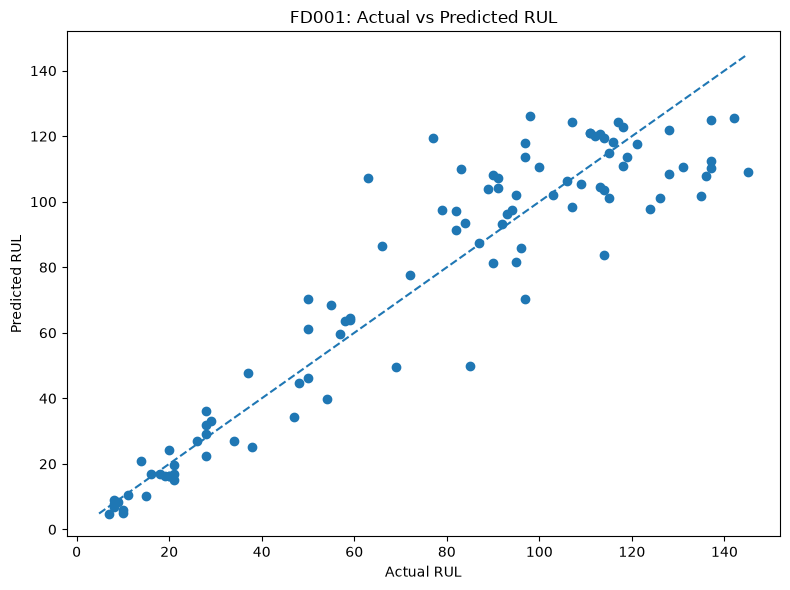

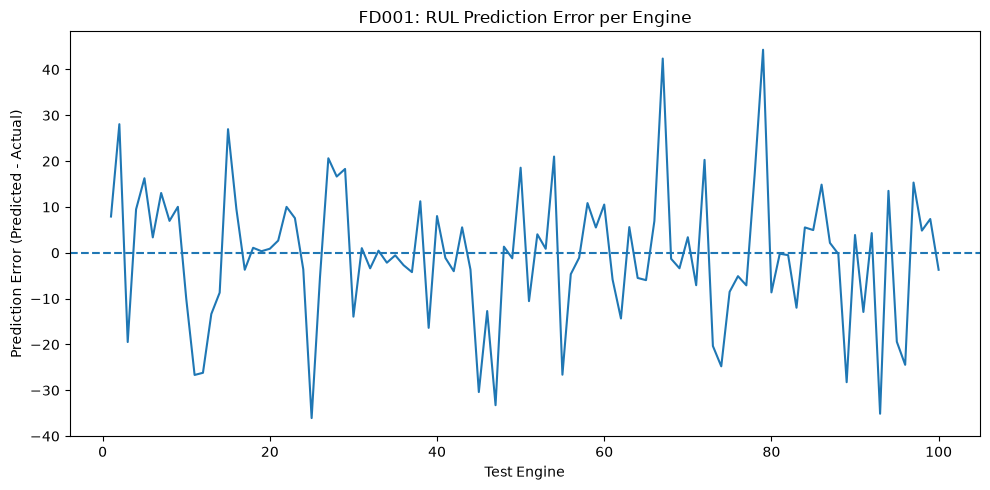

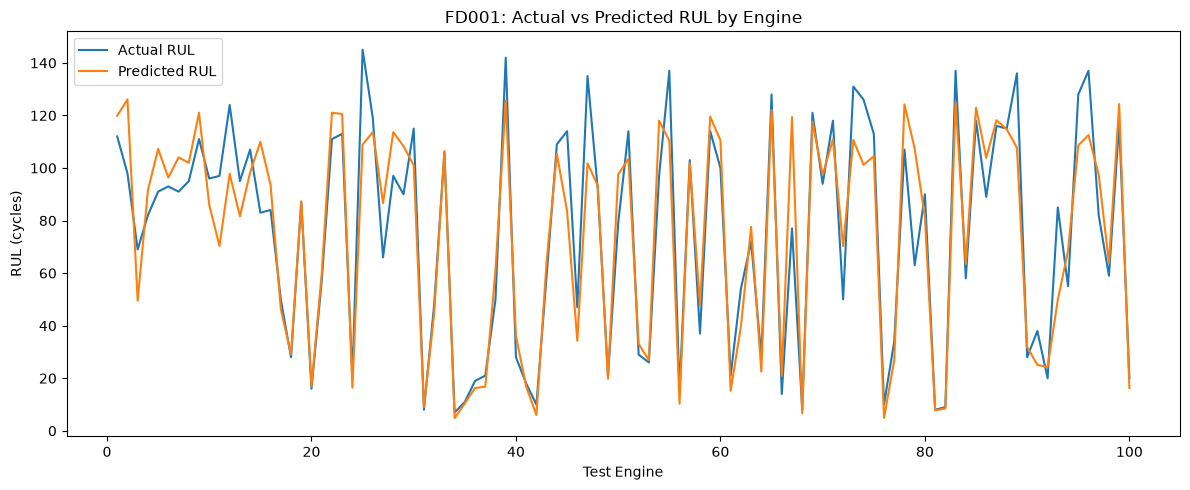

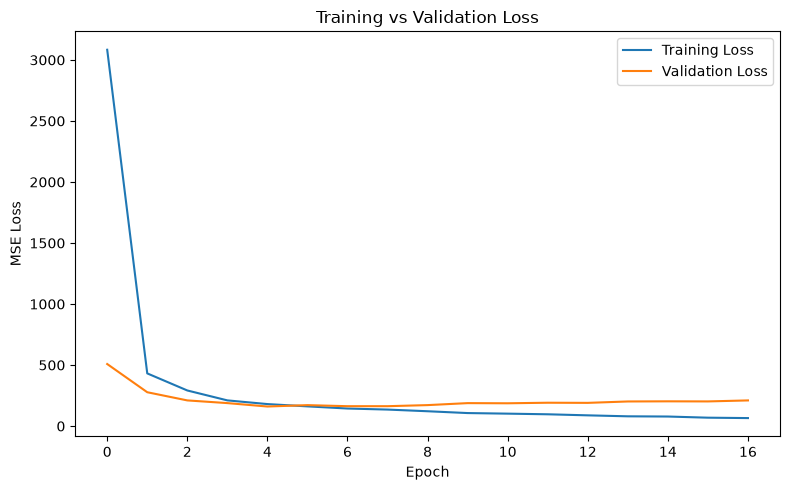


LOCKED FINAL MODEL
Architecture : CNN + LSTM + Attention
Window       : 30 cycles
RUL cap      : 125
Scaler       : StandardScaler
Test set     : Official FD001 / 100 unseen engines

Final metrics:
MAE        : 11.0598
RMSE       : 14.9056
R²         : 0.8713
NASA Score : 390.9042


In [19]:
# ============================================================
# FINAL FD001 EVALUATION
# NASA SCORE + PLOTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. MAKE SURE FINAL PREDICTIONS EXIST
# ============================================================

test_pred = np.asarray(test_pred).ravel()
y_true = np.asarray(y_test_official).ravel()

assert len(test_pred) == 100
assert len(y_true) == 100


# ============================================================
# 2. STANDARD REGRESSION METRICS
# ============================================================

mae = mean_absolute_error(
    y_true,
    test_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        test_pred
    )
)

r2 = r2_score(
    y_true,
    test_pred
)


# ============================================================
# 3. NASA C-MAPSS SCORE
# ============================================================
#
# d = predicted_RUL - actual_RUL
#
# d < 0  -> early prediction
# d >= 0 -> late prediction
#
# Lower NASA score = better
# ============================================================

d = test_pred - y_true

scores = np.where(
    d < 0,
    np.exp(-d / 13.0) - 1.0,
    np.exp(d / 10.0) - 1.0
)

nasa_score = np.sum(scores)


# ============================================================
# 4. ERROR SUMMARY
# ============================================================

under_predictions = np.sum(d < 0)
over_predictions = np.sum(d >= 0)

print("\n========================================")
print("FINAL OFFICIAL FD001 RESULTS")
print("========================================")

print(f"MAE        : {mae:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"R²         : {r2:.4f}")
print(f"NASA Score : {nasa_score:.4f}")

print("\nPrediction direction:")
print("Early / under-predictions :", under_predictions)
print("Late / over-predictions   :", over_predictions)


# ============================================================
# 5. ACTUAL vs PREDICTED RUL
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_true,
    test_pred
)

minimum = min(
    y_true.min(),
    test_pred.min()
)

maximum = max(
    y_true.max(),
    test_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("FD001: Actual vs Predicted RUL")

plt.tight_layout()
plt.show()


# ============================================================
# 6. PREDICTION ERROR PER ENGINE
# ============================================================

errors = test_pred - y_true

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(errors) + 1),
    errors
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Test Engine")
plt.ylabel("Prediction Error (Predicted - Actual)")
plt.title("FD001: RUL Prediction Error per Engine")

plt.tight_layout()
plt.show()


# ============================================================
# 7. ACTUAL AND PREDICTED RUL BY ENGINE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    range(1, 101),
    y_true,
    label="Actual RUL"
)

plt.plot(
    range(1, 101),
    test_pred,
    label="Predicted RUL"
)

plt.xlabel("Test Engine")
plt.ylabel("RUL (cycles)")
plt.title("FD001: Actual vs Predicted RUL by Engine")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 8. TRAINING CURVES
# ============================================================

if "history" in globals():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    if "val_loss" in history.history:

        plt.plot(
            history.history["val_loss"],
            label="Validation Loss"
        )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n========================================")
print("LOCKED FINAL MODEL")
print("========================================")

print("Architecture : CNN + LSTM + Attention")
print("Window       : 30 cycles")
print("RUL cap      : 125")
print("Scaler       : StandardScaler")
print("Test set     : Official FD001 / 100 unseen engines")

print("\nFinal metrics:")
print(f"MAE        : {mae:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"R²         : {r2:.4f}")
print(f"NASA Score : {nasa_score:.4f}")

In [18]:
# ============================================================
# FD001 RUL PREDICTION
# 50-CYCLE IMPROVED MODEL
# ============================================================
#
# CONTROLLED EXPERIMENT:
#
# Previous successful model:
#   Window = 30
#   RUL cap = 125
#   StandardScaler
#   Variance-based feature selection
#   CNN + LSTM + Attention
#   RMSE = 16.33
#
# THIS VERSION:
#   Window = 50
#
# EVERYTHING ELSE REMAINS THE SAME.
#
# Research repository ablation:
#   w50_cap125 -> RMSE 15.52
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras import (
    Model,
    Input
)

from tensorflow.keras.layers import (
    Conv1D,
    LSTM,
    Dense,
    Dropout,
    ReLU,
    Multiply,
    Lambda,
    Softmax
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    Callback
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 3. CONFIGURATION
# ============================================================

SEQ_LEN = 50

STRIDE = 1

RUL_CAP = 125

VAL_RATIO = 0.20

VARIANCE_THRESHOLD = 1e-8

BATCH_SIZE = 64

EPOCHS = 80

LEARNING_RATE = 0.0005

HIDDEN_SIZE = 128

CNN_CHANNELS = 64

DROPOUT = 0.1


# ============================================================
# 4. FILE PATHS
# ============================================================

TRAIN_PATH = "../dataset/train_FD001.txt"

TEST_PATH = "../dataset/test_FD001.txt"

RUL_PATH = "../dataset/RUL_FD001.txt"


# ============================================================
# 5. CHECK FILES
# ============================================================

for path in [
    TRAIN_PATH,
    TEST_PATH,
    RUL_PATH
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nFile not found:\n{path}\n\n"
            "Please correct the dataset path."
        )


print("All dataset files found.")


# ============================================================
# 6. COLUMN NAMES
# ============================================================

SETTING_COLUMNS = [
    "setting_1",
    "setting_2",
    "setting_3"
]

SENSOR_COLUMNS = [
    f"sensor_{i}"
    for i in range(1, 22)
]

COLUMNS = [
    "unit",
    "cycle",
    *SETTING_COLUMNS,
    *SENSOR_COLUMNS
]


# ============================================================
# 7. LOAD TRAIN DATA
# ============================================================

train_full = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
)

train_full.columns = COLUMNS


# ============================================================
# 8. LOAD TEST DATA
# ============================================================

test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
)

test_df.columns = COLUMNS


# ============================================================
# 9. LOAD OFFICIAL RUL
# ============================================================

official_rul = pd.read_csv(
    RUL_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
).iloc[:, 0].to_numpy(
    dtype=np.float32
)


print("\n========================================")
print("DATA LOADED")
print("========================================")

print("Train:", train_full.shape)

print("Test :", test_df.shape)

print("RUL  :", official_rul.shape)


# ============================================================
# 10. TRAIN RUL
# ============================================================

max_cycles = train_full.groupby(
    "unit"
)["cycle"].transform("max")


train_full["rul"] = (
    max_cycles
    - train_full["cycle"]
)


# RUL CAP = 125

train_full["rul"] = train_full[
    "rul"
].clip(
    upper=RUL_CAP
)


# ============================================================
# 11. ENGINE-LEVEL TRAIN / VALIDATION SPLIT
# ============================================================

all_units = sorted(
    train_full["unit"].unique()
)


train_units, val_units = train_test_split(
    all_units,
    test_size=VAL_RATIO,
    random_state=42
)


train_units = sorted(
    train_units
)

val_units = sorted(
    val_units
)


train_df = train_full[
    train_full["unit"].isin(
        train_units
    )
].copy()


val_df = train_full[
    train_full["unit"].isin(
        val_units
    )
].copy()


print("\n========================================")
print("ENGINE SPLIT")
print("========================================")

print(
    "Training engines  :",
    len(train_units)
)

print(
    "Validation engines:",
    len(val_units)
)


# ============================================================
# 12. FEATURE SELECTION
# ============================================================
#
# Same successful pipeline:
#
# settings + all 21 sensors
# ↓
# remove near-zero variance
#
# This should give the same feature set as our
# previous successful 30-cycle experiment.
# ============================================================

candidate_features = (
    SETTING_COLUMNS
    + SENSOR_COLUMNS
)


feature_variances = train_df[
    candidate_features
].var(
    axis=0
)


FEATURES = feature_variances[
    feature_variances
    > VARIANCE_THRESHOLD
].index.tolist()


print("\n========================================")
print("FEATURES")
print("========================================")

print(
    FEATURES
)

print(
    "Number of features:",
    len(FEATURES)
)


# ============================================================
# 13. ADD TEST RUL
# ============================================================
#
# Test RUL at each observed cycle:
#
# final official RUL
# + max observed cycle
# - current cycle
#
# Then cap at 125 for the research-style pipeline.
# ============================================================

official_rul_series = pd.Series(
    official_rul,
    index=np.arange(
        1,
        len(official_rul) + 1
    )
)


test_max_cycles = test_df.groupby(
    "unit"
)["cycle"].transform("max")


test_df["rul"] = (
    test_max_cycles
    - test_df["cycle"]
    + test_df["unit"].map(
        official_rul_series
    )
)


test_df["rul"] = test_df[
    "rul"
].clip(
    upper=RUL_CAP
)


# ============================================================
# 14. STANDARD SCALER
# ============================================================
#
# IMPORTANT:
# Fit ONLY on training engines.
#
# Also use separate float DataFrames so we never hit
# the previous pandas int64 error.
# ============================================================

train_values = train_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)

val_values = val_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)

test_values = test_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)


scaler = StandardScaler()


train_scaled_values = scaler.fit_transform(
    train_values
).astype(np.float32)


val_scaled_values = scaler.transform(
    val_values
).astype(np.float32)


test_scaled_values = scaler.transform(
    test_values
).astype(np.float32)


# Create fresh copies

train_scaled = train_df.copy()

val_scaled = val_df.copy()

test_scaled = test_df.copy()


# Remove original feature columns

train_scaled = train_scaled.drop(
    columns=FEATURES
)

val_scaled = val_scaled.drop(
    columns=FEATURES
)

test_scaled = test_scaled.drop(
    columns=FEATURES
)


# Create FLOAT scaled feature DataFrames

train_feature_df = pd.DataFrame(
    train_scaled_values,
    columns=FEATURES,
    index=train_df.index
)

val_feature_df = pd.DataFrame(
    val_scaled_values,
    columns=FEATURES,
    index=val_df.index
)

test_feature_df = pd.DataFrame(
    test_scaled_values,
    columns=FEATURES,
    index=test_df.index
)


# Combine

train_scaled = pd.concat(
    [
        train_scaled,
        train_feature_df
    ],
    axis=1
)

val_scaled = pd.concat(
    [
        val_scaled,
        val_feature_df
    ],
    axis=1
)

test_scaled = pd.concat(
    [
        test_scaled,
        test_feature_df
    ],
    axis=1
)


print("\n========================================")
print("SCALING")
print("========================================")

print(
    "StandardScaler completed."
)


# ============================================================
# 15. WINDOW CREATION FUNCTION
# ============================================================

def make_windows(
    df,
    feature_cols,
    window_size,
    stride
):

    windows = []

    labels = []

    units = []

    ending_cycles = []


    for unit, group in df.groupby(
        "unit",
        sort=True
    ):

        group = group.sort_values(
            "cycle"
        )


        values = group[
            feature_cols
        ].to_numpy(
            dtype=np.float32
        )


        ruls = group[
            "rul"
        ].to_numpy(
            dtype=np.float32
        )


        cycles = group[
            "cycle"
        ].to_numpy(
            dtype=np.int32
        )


        if len(group) < window_size:

            continue


        for start in range(
            0,
            len(group)
            - window_size
            + 1,
            stride
        ):

            end = (
                start
                + window_size
            )


            windows.append(
                values[
                    start:end
                ]
            )


            # RUL at final timestep

            labels.append(
                ruls[end - 1]
            )


            units.append(
                int(unit)
            )


            ending_cycles.append(
                int(cycles[end - 1])
            )


    if len(windows) == 0:

        raise ValueError(
            "No windows were created."
        )


    return (
        np.stack(
            windows
        ).astype(
            np.float32
        ),

        np.asarray(
            labels,
            dtype=np.float32
        ),

        np.asarray(
            units,
            dtype=np.int32
        ),

        np.asarray(
            ending_cycles,
            dtype=np.int32
        )
    )


# ============================================================
# 16. CREATE TRAINING WINDOWS
# ============================================================

X_train, y_train, train_window_units, train_window_cycles = (
    make_windows(
        train_scaled,
        FEATURES,
        SEQ_LEN,
        STRIDE
    )
)


# ============================================================
# 17. CREATE VALIDATION WINDOWS
# ============================================================

X_val, y_val, val_window_units, val_window_cycles = (
    make_windows(
        val_scaled,
        FEATURES,
        SEQ_LEN,
        STRIDE
    )
)


# ============================================================
# 18. CREATE FINAL TEST WINDOWS — INCLUDING SHORT ENGINES
# ============================================================

def make_test_windows_with_padding(
    df,
    feature_cols,
    window_size
):

    windows = []
    units = []
    ending_cycles = []

    for unit in sorted(df["unit"].unique()):

        group = df[
            df["unit"] == unit
        ].sort_values("cycle")

        values = group[
            feature_cols
        ].to_numpy(dtype=np.float32)

        cycles = group[
            "cycle"
        ].to_numpy(dtype=np.int32)

        # At least 50 cycles
        if len(values) >= window_size:

            sequence = values[-window_size:]

        # Fewer than 50 cycles
        else:

            pad_length = (
                window_size - len(values)
            )

            padding = np.repeat(
                values[0:1],
                pad_length,
                axis=0
            )

            sequence = np.vstack([
                padding,
                values
            ])

        windows.append(
            sequence.astype(np.float32)
        )

        units.append(int(unit))

        ending_cycles.append(
            int(cycles[-1])
        )

    return (
        np.stack(windows).astype(np.float32),
        np.asarray(units, dtype=np.int32),
        np.asarray(ending_cycles, dtype=np.int32)
    )


# ============================================================
# OFFICIAL TEST GROUND TRUTH
# ============================================================

official_rul_ordered = official_rul.astype(
    np.float32
)

print(
    "Official RUL shape:",
    official_rul_ordered.shape
)

assert len(official_rul_ordered) == 100


# ============================================================
# BUILD ONE FINAL WINDOW FOR EACH TEST ENGINE
# ============================================================

X_test, test_final_units, test_final_cycles = (
    make_test_windows_with_padding(
        test_scaled,
        FEATURES,
        SEQ_LEN
    )
)


# ============================================================
# FINAL TEST DATA CHECK
# ============================================================

print("\n========================================")
print("FINAL TEST DATA")
print("========================================")

print(
    "X_test:",
    X_test.shape
)

print(
    "Expected:",
    (
        100,
        SEQ_LEN,
        len(FEATURES)
    )
)


# ============================================================
# SAFETY CHECKS
# ============================================================

assert X_test.ndim == 3
assert X_test.shape[0] == 100
assert X_test.shape[1] == 50
assert X_test.shape[2] == len(FEATURES)

print(
    "\nTest shape checks PASSED."
)


# ============================================================
# RESEARCH-PIPELINE TEST TARGET
# ============================================================
#
# Official FD001 test RUL is the correct target for the
# final test point of each engine.
#
# We keep the uncapped official RUL here.
# ============================================================

y_test_official = official_rul_ordered.copy()

assert y_test_official.shape == (100,)

print(
    "Official test target shape:",
    y_test_official.shape
)
# ============================================================
# 20. SAFETY CHECKS
# ============================================================

assert X_train.ndim == 3

assert X_val.ndim == 3

assert X_test.ndim == 3


assert X_train.shape[1] == 50

assert X_val.shape[1] == 50

assert X_test.shape[1] == 50


assert X_train.shape[2] == len(FEATURES)

assert X_val.shape[2] == len(FEATURES)

assert X_test.shape[2] == len(FEATURES)


assert X_test.shape[0] == 100


print("\nShape checks PASSED.")


# ============================================================
# 21. CNN + LSTM + ATTENTION MODEL
# ============================================================

inputs = Input(
    shape=(
        SEQ_LEN,
        len(FEATURES)
    )
)


# ------------------------------------------------------------
# CNN BLOCK 1
# ------------------------------------------------------------

x = Conv1D(
    filters=CNN_CHANNELS,
    kernel_size=3,
    padding="same"
)(inputs)


x = ReLU()(x)


x = Dropout(
    DROPOUT
)(x)


# ------------------------------------------------------------
# CNN BLOCK 2
# ------------------------------------------------------------

x = Conv1D(
    filters=CNN_CHANNELS,
    kernel_size=3,
    padding="same"
)(x)


x = ReLU()(x)


# ------------------------------------------------------------
# LSTM
# ------------------------------------------------------------

lstm_output = LSTM(
    HIDDEN_SIZE,
    return_sequences=True
)(x)


# ------------------------------------------------------------
# LEARNED ATTENTION
# ------------------------------------------------------------

attention_scores = Dense(
    1
)(lstm_output)


attention_weights = Softmax(
    axis=1
)(
    attention_scores
)


weighted_context = Multiply()([
    lstm_output,
    attention_weights
])


# Keras-safe reduction

context = Lambda(
    lambda x: tf.reduce_sum(
        x,
        axis=1
    )
)(
    weighted_context
)


# ------------------------------------------------------------
# DENSE HEAD
# ------------------------------------------------------------

x = Dropout(
    DROPOUT
)(context)


x = Dense(
    64
)(x)


x = ReLU()(x)


outputs = Dense(
    1
)(x)


model = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 22. COMPILE
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="mse",
    metrics=["mae"]
)


print("\n========================================")
print("MODEL")
print("========================================")

model.summary()


# ============================================================
# 23. BEST VALIDATION RMSE CALLBACK
# ============================================================

class BestValidationRMSE(
    Callback
):

    def __init__(
        self,
        X_val,
        y_val
    ):

        super().__init__()

        self.X_val = X_val

        self.y_val = y_val

        self.best_rmse = np.inf

        self.best_weights = None


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        predictions = self.model.predict(
            self.X_val,
            verbose=0
        ).ravel()


        rmse = np.sqrt(
            mean_squared_error(
                self.y_val,
                predictions
            )
        )


        mae = mean_absolute_error(
            self.y_val,
            predictions
        )


        r2 = r2_score(
            self.y_val,
            predictions
        )


        print(
            f" — val_RMSE: {rmse:.4f}"
            f" — val_MAE: {mae:.4f}"
            f" — val_R2: {r2:.4f}"
        )


        if rmse < self.best_rmse:

            self.best_rmse = rmse

            self.best_weights = [
                w.copy()
                for w in self.model.get_weights()
            ]


    def on_train_end(
        self,
        logs=None
    ):

        if self.best_weights is not None:

            self.model.set_weights(
                self.best_weights
            )


best_callback = BestValidationRMSE(
    X_val,
    y_val
)


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=False
)


# ============================================================
# 24. TRAIN
# ============================================================

print("\n========================================")
print("TRAINING 50-CYCLE MODEL")
print("========================================")

history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        best_callback,
        early_stopping
    ],

    verbose=1
)


# ============================================================
# 25. VALIDATION RESULTS
# ============================================================

val_pred = model.predict(
    X_val,
    verbose=0
).ravel()


val_mae = mean_absolute_error(
    y_val,
    val_pred
)


val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)


val_r2 = r2_score(
    y_val,
    val_pred
)


print("\n========================================")
print("50-CYCLE VALIDATION RESULTS")
print("========================================")

print(
    f"MAE : {val_mae:.4f}"
)

print(
    f"RMSE: {val_rmse:.4f}"
)

print(
    f"R²  : {val_r2:.4f}"
)


# ============================================================
# 26. TEST PREDICTION
# ============================================================

test_pred = model.predict(
    X_test,
    verbose=1
).ravel()


# ============================================================
# 27. RESEARCH-PIPELINE TEST SCORE
# ============================================================

research_mae = mean_absolute_error(
    y_test_research,
    test_pred
)


research_rmse = np.sqrt(
    mean_squared_error(
        y_test_research,
        test_pred
    )
)


research_r2 = r2_score(
    y_test_research,
    test_pred
)


print("\n========================================")
print("RESEARCH-PIPELINE TEST RESULTS")
print("========================================")

print(
    f"MAE : {research_mae:.4f}"
)

print(
    f"RMSE: {research_rmse:.4f}"
)

print(
    f"R²  : {research_r2:.4f}"
)


# ============================================================
# 28. RAW OFFICIAL FD001 TEST SCORE
# ============================================================

order = np.argsort(
    test_final_units
)


raw_actual = official_rul[
    test_final_units[order] - 1
]


raw_pred = test_pred[
    order
]


raw_mae = mean_absolute_error(
    raw_actual,
    raw_pred
)


raw_rmse = np.sqrt(
    mean_squared_error(
        raw_actual,
        raw_pred
    )
)


raw_r2 = r2_score(
    raw_actual,
    raw_pred
)


print("\n========================================")
print("RAW OFFICIAL FD001 RESULTS")
print("========================================")

print(
    f"MAE : {raw_mae:.4f}"
)

print(
    f"RMSE: {raw_rmse:.4f}"
)

print(
    f"R²  : {raw_r2:.4f}"
)


# ============================================================
# 29. COMPARE WITH OUR 30-CYCLE MODEL
# ============================================================

PREVIOUS_RMSE = 16.3300

PREVIOUS_R2 = 0.8456


print("\n========================================")
print("30 vs 50 CYCLE COMPARISON")
print("========================================")

print(
    f"30-cycle RMSE : {PREVIOUS_RMSE:.4f}"
)

print(
    f"50-cycle RMSE : {raw_rmse:.4f}"
)

print()

print(
    f"30-cycle R²   : {PREVIOUS_R2:.4f}"
)

print(
    f"50-cycle R²   : {raw_r2:.4f}"
)


if raw_rmse < PREVIOUS_RMSE:

    print(
        "\n✅ 50-CYCLE MODEL IMPROVED RMSE."
    )

else:

    print(
        "\n❌ 50-CYCLE MODEL DID NOT IMPROVE RMSE."
    )


# ============================================================
# 30. PREDICTION TABLE
# ============================================================

results = pd.DataFrame({

    "engine_id":
        test_final_units[order],

    "actual_RUL":
        raw_actual,

    "predicted_RUL":
        raw_pred
})


results["error"] = (
    results["predicted_RUL"]
    - results["actual_RUL"]
)


print("\n========================================")
print("FIRST 20 PREDICTIONS")
print("========================================")

print(
    results.head(20)
)


# ============================================================
# 31. SAVE MODEL
# ============================================================

model.save(
    "../fd001_cnn_lstm_attention_50cycle.keras"
)


joblib.dump(
    scaler,
    "../fd001_scaler_50cycle.pkl"
)


joblib.dump(
    FEATURES,
    "../fd001_features_50cycle.pkl"
)


print("\n========================================")
print("MODEL SAVED")
print("========================================")

print(
    "Model  : ../fd001_cnn_lstm_attention_50cycle.keras"
)

print(
    "Scaler : ../fd001_scaler_50cycle.pkl"
)

print(
    "Window : 50"
)

print(
    "RUL cap: 125"
)

print(
    "Features:",
    FEATURES
)

print("\nDONE.")

All dataset files found.

DATA LOADED
Train: (20631, 26)
Test : (13096, 26)
RUL  : (100,)

ENGINE SPLIT
Training engines  : 80
Validation engines: 20

FEATURES
['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Number of features: 17

SCALING
StandardScaler completed.
Official RUL shape: (100,)

FINAL TEST DATA
X_test: (100, 50, 17)
Expected: (100, 50, 17)

Test shape checks PASSED.
Official test target shape: (100,)

Shape checks PASSED.

MODEL


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 50, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 50, 64)    │      3,328 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_30 (ReLU)     │ (None, 50, 64)    │          0 │ conv1d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 50, 64)    │          0 │ re_lu_30[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 50, 64)    │     12,352 │ dropout_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_31 (ReLU)     │ (None, 50, 64)    │          0 │ conv1d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 50, 128)   │     98,816 │ re_lu_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 50, 1)     │        129 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_9 (Softmax) │ (None, 50, 1)     │          0 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 50, 128)   │          0 │ lstm_6[0][0],     │
│ (Multiply)          │                   │            │ softmax_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 128)       │          0 │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 128)       │          0 │ lambda_5[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 64)        │      8,256 │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_32 (ReLU)     │ (None, 64)        │          0 │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 1)         │         65 │ re_lu_32[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 122,946 (480.26 KB)

 Trainable params: 122,946 (480.26 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING 50-CYCLE MODEL
Epoch 1/80
 71/198 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - loss: 5341.3901 - mae: 62.0376

KeyboardInterrupt: 

In [ ]:
# ============================================================
# FINAL 50-CYCLE MODEL SCORES
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. VALIDATION PREDICTIONS
# ------------------------------------------------------------

val_pred = model.predict(
    X_val,
    verbose=1
).ravel()

val_mae = mean_absolute_error(
    y_val,
    val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

val_r2 = r2_score(
    y_val,
    val_pred
)


print("\n========================================")
print("50-CYCLE VALIDATION RESULTS")
print("========================================")

print(f"MAE : {val_mae:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²  : {val_r2:.4f}")


# ------------------------------------------------------------
# 2. OFFICIAL FD001 TEST PREDICTIONS
# ------------------------------------------------------------

test_pred = model.predict(
    X_test,
    verbose=1
).ravel()


# ------------------------------------------------------------
# 3. OFFICIAL TEST SCORES
# ------------------------------------------------------------

test_mae = mean_absolute_error(
    y_test_official,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_official,
        test_pred
    )
)

test_r2 = r2_score(
    y_test_official,
    test_pred
)


print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


# ------------------------------------------------------------
# 4. COMPARE WITH OUR PREVIOUS 30-CYCLE MODEL
# ------------------------------------------------------------

print("\n========================================")
print("30-CYCLE vs 50-CYCLE")
print("========================================")

print("Previous 30-cycle:")
print("MAE  : 12.1811")
print("RMSE : 16.3300")
print("R²   : 0.8456")

print("\nNew 50-cycle:")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")


if test_rmse < 16.3300:
    print("\n✅ 50-cycle model IMPROVED RMSE.")
else:
    print("\n❌ 50-cycle model did NOT improve RMSE.")


# ------------------------------------------------------------
# 5. PREDICTION TABLE
# ------------------------------------------------------------

results_50 = pd.DataFrame({
    "engine_id": test_final_units,
    "actual_RUL": y_test_official,
    "predicted_RUL": test_pred
})

results_50["error"] = (
    results_50["predicted_RUL"]
    - results_50["actual_RUL"]
)

print("\n========================================")
print("FIRST 20 PREDICTIONS")
print("========================================")

print(
    results_50.head(20)
)

97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step

50-CYCLE VALIDATION RESULTS
MAE : 9.4580
RMSE: 12.4756
R²  : 0.9086
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

OFFICIAL FD001 TEST RESULTS
MAE : 12.3445
RMSE: 16.9373
R²  : 0.8339

30-CYCLE vs 50-CYCLE
Previous 30-cycle:
MAE  : 12.1811
RMSE : 16.3300
R²   : 0.8456

New 50-cycle:
MAE  : 12.3445
RMSE : 16.9373
R²   : 0.8339

❌ 50-cycle model did NOT improve RMSE.

FIRST 20 PREDICTIONS
    engine_id  actual_RUL  predicted_RUL      error
0           1       112.0     120.912338   8.912338
1           2        98.0     118.867218  20.867218
2           3        69.0      66.413971  -2.586029
3           4        82.0      81.388718  -0.611282
4           5        91.0      86.247116  -4.752884
5           6        93.0     116.727600  23.727600
6           7        91.0      92.141945   1.141945
7           8        95.0      88.541428  -6.458572
8           9       111.0     118.387764   7.387764
9          10        96.0      68.527115 -27.472885
10   

In [ ]:
# ============================================================
# FD001 RUL PREDICTION — 15 CYCLE EXPERIMENT
# ============================================================
#
# CONTROLLED EXPERIMENT
#
# Previous winner:
#   30 cycles
#   RUL cap = 125
#   17 features
#   CNN + LSTM + Attention
#   Test RMSE = 16.3300
#   Test R²   = 0.8456
#
# THIS EXPERIMENT:
#   ONLY changes window length:
#   30 cycles -> 15 cycles
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras import Model, Input

from tensorflow.keras.layers import (
    Conv1D,
    LSTM,
    Dense,
    Dropout,
    ReLU,
    Multiply,
    Lambda,
    Softmax
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    Callback
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 3. CONFIGURATION
# ============================================================

SEQ_LEN = 15

STRIDE = 1

RUL_CAP = 125

VAL_RATIO = 0.20

VARIANCE_THRESHOLD = 1e-8

BATCH_SIZE = 64

EPOCHS = 80

LEARNING_RATE = 0.0005

HIDDEN_SIZE = 128

CNN_CHANNELS = 64

DROPOUT = 0.1


# ============================================================
# 4. FILE PATHS
# ============================================================

TRAIN_PATH = "../dataset/train_FD001.txt"
TEST_PATH = "../dataset/test_FD001.txt"
RUL_PATH = "../dataset/RUL_FD001.txt"


# ============================================================
# 5. CHECK FILES
# ============================================================

for path in [
    TRAIN_PATH,
    TEST_PATH,
    RUL_PATH
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nFile not found:\n{path}\n\n"
            "Correct the dataset path."
        )

print("All dataset files found.")


# ============================================================
# 6. COLUMN NAMES
# ============================================================

SETTING_COLUMNS = [
    "setting_1",
    "setting_2",
    "setting_3"
]

SENSOR_COLUMNS = [
    f"sensor_{i}"
    for i in range(1, 22)
]

COLUMNS = [
    "unit",
    "cycle",
    *SETTING_COLUMNS,
    *SENSOR_COLUMNS
]


# ============================================================
# 7. LOAD TRAIN
# ============================================================

train_full = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
)

train_full.columns = COLUMNS


# ============================================================
# 8. LOAD TEST
# ============================================================

test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
)

test_df.columns = COLUMNS


# ============================================================
# 9. LOAD OFFICIAL RUL
# ============================================================

official_rul = pd.read_csv(
    RUL_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
).iloc[:, 0].to_numpy(
    dtype=np.float32
)


print("\n========================================")
print("DATA")
print("========================================")

print("Train:", train_full.shape)
print("Test :", test_df.shape)
print("RUL  :", official_rul.shape)


# ============================================================
# 10. CALCULATE TRAINING RUL
# ============================================================

max_cycles = train_full.groupby(
    "unit"
)["cycle"].transform("max")

train_full["rul"] = (
    max_cycles
    - train_full["cycle"]
)

train_full["rul"] = train_full[
    "rul"
].clip(
    upper=RUL_CAP
)


# ============================================================
# 11. ENGINE-LEVEL TRAIN / VALIDATION SPLIT
# ============================================================

all_units = sorted(
    train_full["unit"].unique()
)

train_units, val_units = train_test_split(
    all_units,
    test_size=VAL_RATIO,
    random_state=42
)

train_units = sorted(train_units)
val_units = sorted(val_units)


train_df = train_full[
    train_full["unit"].isin(train_units)
].copy()

val_df = train_full[
    train_full["unit"].isin(val_units)
].copy()


print("\n========================================")
print("ENGINE SPLIT")
print("========================================")

print("Training engines  :", len(train_units))
print("Validation engines:", len(val_units))


# ============================================================
# 12. FEATURE SELECTION
# ============================================================

candidate_features = (
    SETTING_COLUMNS
    + SENSOR_COLUMNS
)

feature_variances = train_df[
    candidate_features
].var(axis=0)

FEATURES = feature_variances[
    feature_variances > VARIANCE_THRESHOLD
].index.tolist()


print("\n========================================")
print("FEATURES")
print("========================================")

print("Features:", FEATURES)
print("Number of features:", len(FEATURES))


# ============================================================
# 13. CREATE TEST RUL
# ============================================================

test_max_cycles = test_df.groupby(
    "unit"
)["cycle"].transform("max")

official_rul_series = pd.Series(
    official_rul,
    index=np.arange(
        1,
        len(official_rul) + 1
    )
)

test_df["rul"] = (
    test_max_cycles
    - test_df["cycle"]
    + test_df["unit"].map(
        official_rul_series
    )
)

test_df["rul"] = test_df[
    "rul"
].clip(
    upper=RUL_CAP
)


# ============================================================
# 14. STANDARD SCALER
# ============================================================
#
# FIT ONLY ON TRAINING DATA
# ============================================================

train_values = train_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)

val_values = val_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)

test_values = test_df[
    FEATURES
].to_numpy(
    dtype=np.float32
)


scaler = StandardScaler()


train_scaled_values = scaler.fit_transform(
    train_values
).astype(np.float32)

val_scaled_values = scaler.transform(
    val_values
).astype(np.float32)

test_scaled_values = scaler.transform(
    test_values
).astype(np.float32)


# Fresh dataframes avoid int64 assignment errors

train_scaled = train_df.drop(
    columns=FEATURES
).copy()

val_scaled = val_df.drop(
    columns=FEATURES
).copy()

test_scaled = test_df.drop(
    columns=FEATURES
).copy()


train_feature_df = pd.DataFrame(
    train_scaled_values,
    columns=FEATURES,
    index=train_df.index
)

val_feature_df = pd.DataFrame(
    val_scaled_values,
    columns=FEATURES,
    index=val_df.index
)

test_feature_df = pd.DataFrame(
    test_scaled_values,
    columns=FEATURES,
    index=test_df.index
)


train_scaled = pd.concat(
    [
        train_scaled,
        train_feature_df
    ],
    axis=1
)

val_scaled = pd.concat(
    [
        val_scaled,
        val_feature_df
    ],
    axis=1
)

test_scaled = pd.concat(
    [
        test_scaled,
        test_feature_df
    ],
    axis=1
)


print("\n========================================")
print("SCALING")
print("========================================")

print("StandardScaler completed.")


# ============================================================
# 15. TRAIN / VALIDATION WINDOW FUNCTION
# ============================================================

def make_windows(
    df,
    feature_cols,
    window_size,
    stride
):

    windows = []
    labels = []
    units = []
    ending_cycles = []


    for unit, group in df.groupby(
        "unit",
        sort=True
    ):

        group = group.sort_values(
            "cycle"
        )


        values = group[
            feature_cols
        ].to_numpy(
            dtype=np.float32
        )


        ruls = group[
            "rul"
        ].to_numpy(
            dtype=np.float32
        )


        cycles = group[
            "cycle"
        ].to_numpy(
            dtype=np.int32
        )


        if len(group) < window_size:
            continue


        for start in range(
            0,
            len(group) - window_size + 1,
            stride
        ):

            end = (
                start
                + window_size
            )


            windows.append(
                values[start:end]
            )


            labels.append(
                ruls[end - 1]
            )


            units.append(
                int(unit)
            )


            ending_cycles.append(
                int(cycles[end - 1])
            )


    return (
        np.stack(windows).astype(np.float32),
        np.asarray(labels, dtype=np.float32),
        np.asarray(units, dtype=np.int32),
        np.asarray(ending_cycles, dtype=np.int32)
    )


# ============================================================
# 16. CREATE TRAINING WINDOWS
# ============================================================

X_train, y_train, _, _ = make_windows(
    train_scaled,
    FEATURES,
    SEQ_LEN,
    STRIDE
)


# ============================================================
# 17. CREATE VALIDATION WINDOWS
# ============================================================

X_val, y_val, _, _ = make_windows(
    val_scaled,
    FEATURES,
    SEQ_LEN,
    STRIDE
)


print("\n========================================")
print("15-CYCLE WINDOWS")
print("========================================")

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)


# ============================================================
# 18. OFFICIAL TEST WINDOW FUNCTION
# ============================================================
#
# Every test engine must produce exactly ONE sequence.
#
# If engine has <15 cycles:
# repeat its first observation for padding.
#
# ============================================================

def make_test_windows_with_padding(
    df,
    feature_cols,
    window_size
):

    windows = []
    units = []
    ending_cycles = []


    for unit in sorted(
        df["unit"].unique()
    ):

        group = df[
            df["unit"] == unit
        ].sort_values(
            "cycle"
        )


        values = group[
            feature_cols
        ].to_numpy(
            dtype=np.float32
        )


        cycles = group[
            "cycle"
        ].to_numpy(
            dtype=np.int32
        )


        if len(values) >= window_size:

            sequence = values[
                -window_size:
            ]

        else:

            pad_length = (
                window_size
                - len(values)
            )


            padding = np.repeat(
                values[0:1],
                pad_length,
                axis=0
            )


            sequence = np.vstack([
                padding,
                values
            ])


        windows.append(
            sequence.astype(
                np.float32
            )
        )


        units.append(
            int(unit)
        )


        ending_cycles.append(
            int(cycles[-1])
        )


    return (
        np.stack(windows).astype(
            np.float32
        ),

        np.asarray(
            units,
            dtype=np.int32
        ),

        np.asarray(
            ending_cycles,
            dtype=np.int32
        )
    )


# ============================================================
# 19. BUILD OFFICIAL TEST DATA
# ============================================================

X_test, test_final_units, test_final_cycles = (
    make_test_windows_with_padding(
        test_scaled,
        FEATURES,
        SEQ_LEN
    )
)


y_test_official = official_rul.astype(
    np.float32
)


print("\n========================================")
print("FINAL TEST DATA")
print("========================================")

print(
    "X_test:",
    X_test.shape
)

print(
    "Expected:",
    (
        100,
        15,
        len(FEATURES)
    )
)


# ============================================================
# 20. SAFETY CHECKS
# ============================================================

assert X_train.ndim == 3
assert X_val.ndim == 3
assert X_test.ndim == 3

assert X_train.shape[1] == 15
assert X_val.shape[1] == 15
assert X_test.shape[1] == 15

assert X_train.shape[2] == len(FEATURES)
assert X_val.shape[2] == len(FEATURES)
assert X_test.shape[2] == len(FEATURES)

assert X_test.shape[0] == 100
assert y_test_official.shape[0] == 100


print(
    "\nShape checks PASSED."
)


# ============================================================
# 21. CNN + LSTM + ATTENTION
# ============================================================

inputs = Input(
    shape=(
        SEQ_LEN,
        len(FEATURES)
    )
)


# CNN
x = Conv1D(
    filters=CNN_CHANNELS,
    kernel_size=3,
    padding="same"
)(inputs)

x = ReLU()(x)

x = Dropout(
    DROPOUT
)(x)


# Second CNN
x = Conv1D(
    filters=CNN_CHANNELS,
    kernel_size=3,
    padding="same"
)(x)

x = ReLU()(x)


# LSTM
lstm_output = LSTM(
    HIDDEN_SIZE,
    return_sequences=True
)(x)


# Attention
attention_scores = Dense(
    1
)(lstm_output)

attention_weights = Softmax(
    axis=1
)(
    attention_scores
)


weighted_context = Multiply()([
    lstm_output,
    attention_weights
])


context = Lambda(
    lambda x: tf.reduce_sum(
        x,
        axis=1
    )
)(
    weighted_context
)


# Dense head
x = Dropout(
    DROPOUT
)(context)

x = Dense(
    64
)(x)

x = ReLU()(x)

outputs = Dense(
    1
)(x)


model = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 22. COMPILE
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="mse",
    metrics=["mae"]
)


print("\n========================================")
print("MODEL")
print("========================================")

model.summary()


# ============================================================
# 23. BEST VALIDATION RMSE CALLBACK
# ============================================================

class BestValidationRMSE(
    Callback
):

    def __init__(
        self,
        X_val,
        y_val
    ):

        super().__init__()

        self.X_val = X_val
        self.y_val = y_val

        self.best_rmse = np.inf
        self.best_weights = None


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        predictions = self.model.predict(
            self.X_val,
            verbose=0
        ).ravel()


        rmse = np.sqrt(
            mean_squared_error(
                self.y_val,
                predictions
            )
        )


        mae = mean_absolute_error(
            self.y_val,
            predictions
        )


        r2 = r2_score(
            self.y_val,
            predictions
        )


        print(
            f" — val_RMSE: {rmse:.4f}"
            f" — val_MAE: {mae:.4f}"
            f" — val_R2: {r2:.4f}"
        )


        if rmse < self.best_rmse:

            self.best_rmse = rmse

            self.best_weights = [
                w.copy()
                for w in self.model.get_weights()
            ]


    def on_train_end(
        self,
        logs=None
    ):

        if self.best_weights is not None:

            self.model.set_weights(
                self.best_weights
            )


best_callback = BestValidationRMSE(
    X_val,
    y_val
)


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=False
)


# ============================================================
# 24. TRAIN
# ============================================================

print("\n========================================")
print("TRAINING 15-CYCLE MODEL")
print("========================================")


history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        best_callback,
        early_stopping
    ],

    verbose=1
)


# ============================================================
# 25. VALIDATION RESULTS
# ============================================================

val_pred = model.predict(
    X_val,
    verbose=1
).ravel()


val_mae = mean_absolute_error(
    y_val,
    val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

val_r2 = r2_score(
    y_val,
    val_pred
)


print("\n========================================")
print("15-CYCLE VALIDATION RESULTS")
print("========================================")

print(
    f"MAE : {val_mae:.4f}"
)

print(
    f"RMSE: {val_rmse:.4f}"
)

print(
    f"R²  : {val_r2:.4f}"
)


# ============================================================
# 26. OFFICIAL TEST PREDICTIONS
# ============================================================

test_pred = model.predict(
    X_test,
    verbose=1
).ravel()


# ============================================================
# 27. OFFICIAL TEST RESULTS
# ============================================================

test_mae = mean_absolute_error(
    y_test_official,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_official,
        test_pred
    )
)

test_r2 = r2_score(
    y_test_official,
    test_pred
)


print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(
    f"MAE : {test_mae:.4f}"
)

print(
    f"RMSE: {test_rmse:.4f}"
)

print(
    f"R²  : {test_r2:.4f}"
)


# ============================================================
# 28. COMPARE AGAINST 30-CYCLE WINNER
# ============================================================

PREVIOUS_MAE = 12.1811
PREVIOUS_RMSE = 16.3300
PREVIOUS_R2 = 0.8456


print("\n========================================")
print("15 vs 30 CYCLE")
print("========================================")

print("\n30-CYCLE WINNER:")
print(
    f"MAE : {PREVIOUS_MAE:.4f}"
)
print(
    f"RMSE: {PREVIOUS_RMSE:.4f}"
)
print(
    f"R²  : {PREVIOUS_R2:.4f}"
)


print("\n15-CYCLE MODEL:")
print(
    f"MAE : {test_mae:.4f}"
)
print(
    f"RMSE: {test_rmse:.4f}"
)
print(
    f"R²  : {test_r2:.4f}"
)


if test_rmse < PREVIOUS_RMSE:

    print(
        "\n✅ 15-CYCLE MODEL IMPROVED RMSE."
    )

else:

    print(
        "\n❌ 15-CYCLE MODEL DID NOT IMPROVE."
    )


# ============================================================
# 29. PREDICTION TABLE
# ============================================================

results_15 = pd.DataFrame({

    "engine_id":
        test_final_units,

    "actual_RUL":
        y_test_official,

    "predicted_RUL":
        test_pred
})


results_15["error"] = (
    results_15["predicted_RUL"]
    - results_15["actual_RUL"]
)


print("\n========================================")
print("FIRST 20 PREDICTIONS")
print("========================================")

print(
    results_15.head(20)
)


# ============================================================
# 30. SAVE MODEL
# ============================================================

model.save(
    "../fd001_cnn_lstm_attention_15cycle.keras"
)

joblib.dump(
    scaler,
    "../fd001_scaler_15cycle.pkl"
)

joblib.dump(
    FEATURES,
    "../fd001_features_15cycle.pkl"
)


print("\n========================================")
print("15-CYCLE MODEL SAVED")
print("========================================")

print(
    "../fd001_cnn_lstm_attention_15cycle.keras"
)

print("\nDONE.")

All dataset files found.

DATA
Train: (20631, 26)
Test : (13096, 26)
RUL  : (100,)

ENGINE SPLIT
Training engines  : 80
Validation engines: 20

FEATURES
Features: ['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Number of features: 17

SCALING
StandardScaler completed.

15-CYCLE WINDOWS
X_train: (15441, 15, 17)
X_val  : (3790, 15, 17)

FINAL TEST DATA
X_test: (100, 15, 17)
Expected: (100, 15, 17)

Shape checks PASSED.

MODEL


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 15, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 15, 64)    │      3,328 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 15, 64)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 15, 64)    │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 15, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 15, 64)    │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 15, 128)   │     98,816 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 15, 1)     │        129 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 15, 1)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 15, 128)   │          0 │ lstm_1[0][0],     │
│ (Multiply)          │                   │            │ softmax_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128)       │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ re_lu_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 122,946 (480.26 KB)

 Trainable params: 122,946 (480.26 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING 15-CYCLE MODEL
Epoch 1/80
241/242 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2631.9219 - mae: 39.9921 — val_RMSE: 19.1428 — val_MAE: 15.7148 — val_R2: 0.7906
242/242 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 2629.3921 - mae: 39.9667 - val_loss: 366.4452 - val_mae: 15.7148
Epoch 2/80
240/242 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 360.3372 - mae: 14.7421 — val_RMSE: 16.1968 — val_MAE: 11.9051 — val_R2: 0.8501
242/242 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 359.8131 - mae: 14.7264 - val_loss: 262.3351 - val_mae: 11.9051
Epoch 3/80
241/242 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 309.3089 - mae: 13.2655 — val_RMSE: 15.3818 — val_MAE: 11.3464 — val_R2: 0.8648
242/242 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 309.0694 - mae: 13.2587 - val_loss: 236.5994 - val_mae: 11.3464
Epoch 4/80
241/242 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 280.6921 - mae: 12.5330 — val_RMSE: 15.2944 — val_MAE: 11.1358 — val_R2: 0.8663
242/242 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 280.4822 - mae:

In [ ]:
# ============================================================
# 15-CYCLE MODEL — FINAL SCORES
# ============================================================

import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

val_pred = model.predict(
    X_val,
    verbose=1
).ravel()

val_mae = mean_absolute_error(
    y_val,
    val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

val_r2 = r2_score(
    y_val,
    val_pred
)


print("\n========================================")
print("15-CYCLE VALIDATION RESULTS")
print("========================================")

print(f"MAE : {val_mae:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²  : {val_r2:.4f}")


# ------------------------------------------------------------
# OFFICIAL FD001 TEST
# ------------------------------------------------------------

test_pred = model.predict(
    X_test,
    verbose=1
).ravel()

test_mae = mean_absolute_error(
    y_test_official,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_official,
        test_pred
    )
)

test_r2 = r2_score(
    y_test_official,
    test_pred
)


print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


# ------------------------------------------------------------
# COMPARE WITH 30-CYCLE WINNER
# ------------------------------------------------------------

print("\n========================================")
print("30-CYCLE vs 15-CYCLE")
print("========================================")

print("\n30-CYCLE:")
print("MAE : 12.1811")
print("RMSE: 16.3300")
print("R²  : 0.8456")

print("\n15-CYCLE:")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step

15-CYCLE VALIDATION RESULTS
MAE : 11.1358
RMSE: 15.2944
R²  : 0.8663
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

OFFICIAL FD001 TEST RESULTS
MAE : 12.1289
RMSE: 17.0118
R²  : 0.8324

30-CYCLE vs 15-CYCLE

30-CYCLE:
MAE : 12.1811
RMSE: 16.3300
R²  : 0.8456

15-CYCLE:
MAE : 12.1289
RMSE: 17.0118
R²  : 0.8324


In [ ]:
# ============================================================
# FD001 — TCN RUL MODEL
# ============================================================
#
# CONTROLLED EXPERIMENT AGAINST OUR WINNING MODEL
#
# Current winner:
#   CNN + LSTM + Attention
#   Window = 30
#   RUL cap = 125
#   Test RMSE = 16.3300
#   Test R²   = 0.8456
#
# THIS MODEL:
#   TCN
#   Window = 30
#   RUL cap = 125
#   Same features
#   Same scaler
#   Same engine split
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras import Model, Input

from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    ReLU,
    Add,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import (
    Callback,
    EarlyStopping,
    ReduceLROnPlateau
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. CONFIGURATION
# ============================================================

SEQ_LEN = 30

STRIDE = 1

RUL_CAP = 125

VAL_RATIO = 0.20

BATCH_SIZE = 64

EPOCHS = 80

LEARNING_RATE = 0.001

DROPOUT = 0.10

TCN_FILTERS = 64

KERNEL_SIZE = 3

DILATIONS = [1, 2, 4, 8]


# ============================================================
# 4. FILE PATHS
# ============================================================

TRAIN_PATH = "../dataset/train_FD001.txt"
TEST_PATH = "../dataset/test_FD001.txt"
RUL_PATH = "../dataset/RUL_FD001.txt"


# ============================================================
# 5. CHECK FILES
# ============================================================

for path in [
    TRAIN_PATH,
    TEST_PATH,
    RUL_PATH
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nFile not found:\n{path}\n\n"
            "Check TRAIN_PATH / TEST_PATH / RUL_PATH."
        )

print("Dataset files found.")


# ============================================================
# 6. COLUMN NAMES
# ============================================================

SETTING_COLUMNS = [
    "setting_1",
    "setting_2",
    "setting_3"
]

SENSOR_COLUMNS = [
    f"sensor_{i}"
    for i in range(1, 22)
]

COLUMNS = [
    "unit",
    "cycle",
    *SETTING_COLUMNS,
    *SENSOR_COLUMNS
]


# ============================================================
# 7. LOAD DATA
# ============================================================

train_full = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
)

train_full.columns = COLUMNS


test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
)

test_df.columns = COLUMNS


official_rul = pd.read_csv(
    RUL_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
).iloc[:, 0].to_numpy(
    dtype=np.float32
)


print("\n========================================")
print("DATA")
print("========================================")

print("Train:", train_full.shape)
print("Test :", test_df.shape)
print("RUL  :", official_rul.shape)


# ============================================================
# 8. TRAINING RUL
# ============================================================

max_cycle = train_full.groupby(
    "unit"
)["cycle"].transform("max")

train_full["rul"] = (
    max_cycle
    - train_full["cycle"]
)

train_full["rul"] = train_full[
    "rul"
].clip(
    upper=RUL_CAP
)


# ============================================================
# 9. ENGINE-LEVEL TRAIN / VALIDATION SPLIT
# ============================================================

all_units = sorted(
    train_full["unit"].unique()
)

train_units, val_units = train_test_split(
    all_units,
    test_size=VAL_RATIO,
    random_state=SEED
)

train_units = sorted(train_units)
val_units = sorted(val_units)


train_df = train_full[
    train_full["unit"].isin(train_units)
].copy()

val_df = train_full[
    train_full["unit"].isin(val_units)
].copy()


print("\n========================================")
print("ENGINE SPLIT")
print("========================================")

print(
    "Training engines  :",
    len(train_units)
)

print(
    "Validation engines:",
    len(val_units)
)


# ============================================================
# 10. FEATURE SELECTION
# ============================================================

candidate_features = (
    SETTING_COLUMNS
    + SENSOR_COLUMNS
)

feature_variances = train_df[
    candidate_features
].var(axis=0)

FEATURES = feature_variances[
    feature_variances > 1e-8
].index.tolist()


print("\n========================================")
print("FEATURES")
print("========================================")

print(
    "Number of features:",
    len(FEATURES)
)

print(
    FEATURES
)


# ============================================================
# 11. STANDARD SCALING
# ============================================================
#
# FIT ONLY ON TRAINING ENGINES.
# ============================================================

scaler = StandardScaler()


train_scaled_values = scaler.fit_transform(
    train_df[FEATURES].to_numpy(
        dtype=np.float32
    )
).astype(np.float32)


val_scaled_values = scaler.transform(
    val_df[FEATURES].to_numpy(
        dtype=np.float32
    )
).astype(np.float32)


test_scaled_values = scaler.transform(
    test_df[FEATURES].to_numpy(
        dtype=np.float32
    )
).astype(np.float32)


# Rebuild dataframes to avoid pandas dtype assignment errors

train_scaled = train_df.drop(
    columns=FEATURES
).copy()

val_scaled = val_df.drop(
    columns=FEATURES
).copy()

test_scaled = test_df.drop(
    columns=FEATURES
).copy()


train_feature_df = pd.DataFrame(
    train_scaled_values,
    columns=FEATURES,
    index=train_df.index
)

val_feature_df = pd.DataFrame(
    val_scaled_values,
    columns=FEATURES,
    index=val_df.index
)

test_feature_df = pd.DataFrame(
    test_scaled_values,
    columns=FEATURES,
    index=test_df.index
)


train_scaled = pd.concat(
    [
        train_scaled,
        train_feature_df
    ],
    axis=1
)


val_scaled = pd.concat(
    [
        val_scaled,
        val_feature_df
    ],
    axis=1
)


test_scaled = pd.concat(
    [
        test_scaled,
        test_feature_df
    ],
    axis=1
)


print("\n========================================")
print("SCALING")
print("========================================")

print("StandardScaler completed.")


# ============================================================
# 12. WINDOW CREATION
# ============================================================

def make_windows(
    df,
    feature_cols,
    window_size,
    stride
):

    X = []
    y = []
    units = []
    cycles = []


    for unit, group in df.groupby(
        "unit",
        sort=True
    ):

        group = group.sort_values(
            "cycle"
        )


        values = group[
            feature_cols
        ].to_numpy(
            dtype=np.float32
        )


        rul_values = group[
            "rul"
        ].to_numpy(
            dtype=np.float32
        )


        cycle_values = group[
            "cycle"
        ].to_numpy(
            dtype=np.int32
        )


        if len(values) < window_size:
            continue


        for start in range(
            0,
            len(values) - window_size + 1,
            stride
        ):

            end = (
                start
                + window_size
            )


            X.append(
                values[start:end]
            )


            y.append(
                rul_values[end - 1]
            )


            units.append(
                int(unit)
            )


            cycles.append(
                int(cycle_values[end - 1])
            )


    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(units, dtype=np.int32),
        np.asarray(cycles, dtype=np.int32)
    )


# ============================================================
# 13. TRAIN WINDOWS
# ============================================================

X_train, y_train, _, _ = make_windows(
    train_scaled,
    FEATURES,
    SEQ_LEN,
    STRIDE
)


# ============================================================
# 14. VALIDATION WINDOWS
# ============================================================

X_val, y_val, _, _ = make_windows(
    val_scaled,
    FEATURES,
    SEQ_LEN,
    STRIDE
)


print("\n========================================")
print("WINDOWS")
print("========================================")

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "y_val:",
    y_val.shape
)


# ============================================================
# 15. OFFICIAL TEST WINDOWS
# ============================================================
#
# ONE FINAL WINDOW PER TEST ENGINE.
#
# Engines shorter than 30 cycles are padded using
# their first observed scaled row.
# ============================================================

def make_test_windows(
    df,
    feature_cols,
    window_size
):

    windows = []
    units = []
    ending_cycles = []


    for unit in sorted(
        df["unit"].unique()
    ):

        group = df[
            df["unit"] == unit
        ].sort_values(
            "cycle"
        )


        values = group[
            feature_cols
        ].to_numpy(
            dtype=np.float32
        )


        cycles = group[
            "cycle"
        ].to_numpy(
            dtype=np.int32
        )


        if len(values) >= window_size:

            sequence = values[
                -window_size:
            ]


        else:

            pad_length = (
                window_size
                - len(values)
            )


            padding = np.repeat(
                values[0:1],
                pad_length,
                axis=0
            )


            sequence = np.vstack([
                padding,
                values
            ])


        windows.append(
            sequence.astype(
                np.float32
            )
        )


        units.append(
            int(unit)
        )


        ending_cycles.append(
            int(cycles[-1])
        )


    return (
        np.stack(windows).astype(
            np.float32
        ),

        np.asarray(
            units,
            dtype=np.int32
        ),

        np.asarray(
            ending_cycles,
            dtype=np.int32
        )
    )


X_test, test_final_units, test_final_cycles = (
    make_test_windows(
        test_scaled,
        FEATURES,
        SEQ_LEN
    )
)


y_test_official = official_rul.astype(
    np.float32
)


print("\n========================================")
print("TEST DATA")
print("========================================")

print(
    "X_test:",
    X_test.shape
)

print(
    "Official RUL:",
    y_test_official.shape
)


# ============================================================
# 16. SHAPE CHECKS
# ============================================================

assert X_train.ndim == 3
assert X_val.ndim == 3
assert X_test.ndim == 3

assert X_train.shape[1] == SEQ_LEN
assert X_val.shape[1] == SEQ_LEN
assert X_test.shape[1] == SEQ_LEN

assert X_train.shape[2] == len(FEATURES)
assert X_val.shape[2] == len(FEATURES)
assert X_test.shape[2] == len(FEATURES)

assert X_test.shape[0] == 100
assert y_test_official.shape[0] == 100


print(
    "\nShape checks PASSED."
)


# ============================================================
# 17. TCN RESIDUAL BLOCK
# ============================================================

def tcn_block(
    x,
    filters,
    kernel_size,
    dilation_rate,
    dropout_rate
):

    residual = x


    # First dilated convolution

    y = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate
    )(x)

    y = ReLU()(y)

    y = Dropout(
        dropout_rate
    )(y)


    # Second dilated convolution

    y = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate
    )(y)

    y = ReLU()(y)

    y = Dropout(
        dropout_rate
    )(y)


    # Match residual channels

    if residual.shape[-1] != filters:

        residual = Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same"
        )(residual)


    # Residual connection

    y = Add()([
        residual,
        y
    ])

    y = ReLU()(y)


    return y


# ============================================================
# 18. BUILD TCN MODEL
# ============================================================

inputs = Input(
    shape=(
        SEQ_LEN,
        len(FEATURES)
    )
)


x = inputs


# Dilated TCN blocks:
#
# dilation = 1
# dilation = 2
# dilation = 4
# dilation = 8
#
# This allows the model to see progressively larger
# temporal receptive fields.

for dilation in DILATIONS:

    x = tcn_block(
        x,
        filters=TCN_FILTERS,
        kernel_size=KERNEL_SIZE,
        dilation_rate=dilation,
        dropout_rate=DROPOUT
    )


# Global temporal representation

x = GlobalAveragePooling1D()(x)


# Regression head

x = Dense(64)(x)

x = ReLU()(x)

x = Dropout(
    DROPOUT
)(x)


outputs = Dense(
    1,
    activation="linear"
)(x)


model = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 19. COMPILE
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="mse",
    metrics=["mae"]
)


print("\n========================================")
print("TCN MODEL")
print("========================================")

model.summary()


# ============================================================
# 20. BEST VALIDATION RMSE CALLBACK
# ============================================================

class BestValidationRMSE(
    Callback
):

    def __init__(
        self,
        X_val,
        y_val
    ):

        super().__init__()

        self.X_val = X_val
        self.y_val = y_val

        self.best_rmse = np.inf
        self.best_weights = None


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        predictions = self.model.predict(
            self.X_val,
            verbose=0
        ).ravel()


        rmse = np.sqrt(
            mean_squared_error(
                self.y_val,
                predictions
            )
        )


        mae = mean_absolute_error(
            self.y_val,
            predictions
        )


        r2 = r2_score(
            self.y_val,
            predictions
        )


        print(
            f" — val_RMSE: {rmse:.4f}"
            f" — val_MAE: {mae:.4f}"
            f" — val_R2: {r2:.4f}"
        )


        if rmse < self.best_rmse:

            self.best_rmse = rmse

            self.best_weights = [
                weight.copy()
                for weight in self.model.get_weights()
            ]


    def on_train_end(
        self,
        logs=None
    ):

        if self.best_weights is not None:

            self.model.set_weights(
                self.best_weights
            )


best_validation_callback = (
    BestValidationRMSE(
        X_val,
        y_val
    )
)


# ============================================================
# 21. EARLY STOPPING
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=False
)


# ============================================================
# 22. LEARNING-RATE REDUCTION
# ============================================================

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# 23. TRAIN
# ============================================================

print("\n========================================")
print("TRAINING TCN")
print("========================================")


history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        best_validation_callback,
        reduce_lr,
        early_stopping
    ],

    verbose=1
)


# ============================================================
# 24. VALIDATION SCORE
# ============================================================

val_pred = model.predict(
    X_val,
    verbose=1
).ravel()


val_mae = mean_absolute_error(
    y_val,
    val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

val_r2 = r2_score(
    y_val,
    val_pred
)


print("\n========================================")
print("TCN VALIDATION RESULTS")
print("========================================")

print(
    f"MAE : {val_mae:.4f}"
)

print(
    f"RMSE: {val_rmse:.4f}"
)

print(
    f"R²  : {val_r2:.4f}"
)


# ============================================================
# 25. OFFICIAL TEST PREDICTION
# ============================================================

test_pred = model.predict(
    X_test,
    verbose=1
).ravel()


# ============================================================
# 26. OFFICIAL FD001 TEST RESULTS
# ============================================================

test_mae = mean_absolute_error(
    y_test_official,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_official,
        test_pred
    )
)

test_r2 = r2_score(
    y_test_official,
    test_pred
)


print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(
    f"MAE : {test_mae:.4f}"
)

print(
    f"RMSE: {test_rmse:.4f}"
)

print(
    f"R²  : {test_r2:.4f}"
)


# ============================================================
# 27. COMPARE WITH OUR CURRENT WINNER
# ============================================================

WINNER_MAE = 12.1811
WINNER_RMSE = 16.3300
WINNER_R2 = 0.8456


print("\n========================================")
print("TCN vs CURRENT WINNER")
print("========================================")

print("\nCURRENT CNN-LSTM-ATTENTION:")
print(
    f"MAE : {WINNER_MAE:.4f}"
)
print(
    f"RMSE: {WINNER_RMSE:.4f}"
)
print(
    f"R²  : {WINNER_R2:.4f}"
)


print("\nTCN:")
print(
    f"MAE : {test_mae:.4f}"
)
print(
    f"RMSE: {test_rmse:.4f}"
)
print(
    f"R²  : {test_r2:.4f}"
)


if test_rmse < WINNER_RMSE:

    print(
        "\n✅ TCN BEAT OUR CURRENT MODEL."
    )

    print(
        f"RMSE improvement: "
        f"{WINNER_RMSE - test_rmse:.4f}"
    )

else:

    print(
        "\n❌ TCN DID NOT BEAT OUR CURRENT MODEL."
    )

    print(
        f"RMSE difference: "
        f"{test_rmse - WINNER_RMSE:.4f}"
    )


# ============================================================
# 28. PREDICTION TABLE
# ============================================================

results_tcn = pd.DataFrame({

    "engine_id":
        test_final_units,

    "actual_RUL":
        y_test_official,

    "predicted_RUL":
        test_pred
})


results_tcn["error"] = (
    results_tcn["predicted_RUL"]
    - results_tcn["actual_RUL"]
)


print("\n========================================")
print("FIRST 20 TEST PREDICTIONS")
print("========================================")

print(
    results_tcn.head(20)
)


# ============================================================
# 29. SAVE TCN MODEL
# ============================================================

MODEL_PATH = (
    "../fd001_tcn_30cycle.keras"
)

SCALER_PATH = (
    "../fd001_tcn_scaler.pkl"
)

FEATURE_PATH = (
    "../fd001_tcn_features.pkl"
)


model.save(
    MODEL_PATH
)

joblib.dump(
    scaler,
    SCALER_PATH
)

joblib.dump(
    FEATURES,
    FEATURE_PATH
)


print("\n========================================")
print("TCN MODEL SAVED")
print("========================================")

print(
    "Model :",
    MODEL_PATH
)

print(
    "Scaler:",
    SCALER_PATH
)

print(
    "Features:",
    FEATURE_PATH
)

print("\nDONE.")

Dataset files found.

DATA
Train: (20631, 26)
Test : (13096, 26)
RUL  : (100,)

ENGINE SPLIT
Training engines  : 80
Validation engines: 20

FEATURES
Number of features: 17
['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

SCALING
StandardScaler completed.

WINDOWS
X_train: (14241, 30, 17)
y_train: (14241,)
X_val: (3490, 30, 17)
y_val: (3490,)

TEST DATA
X_test: (100, 30, 17)
Official RUL: (100,)

Shape checks PASSED.

TCN MODEL


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 30, 64)    │      3,328 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 30, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 64)    │          0 │ re_lu_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 30, 64)    │          0 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 30, 64)    │      1,152 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 64)    │          0 │ re_lu_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_8 (ReLU)      │ (None, 30, 64)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 30, 64)    │     12,352 │ re_lu_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 30, 64)    │          0 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 30, 64)    │          0 │ re_lu_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 30, 64)    │          0 │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 64)    │          0 │ re_lu_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 64)    │          0 │ re_lu_8[0][0],    │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_11 (ReLU)     │ (None, 30, 64)    │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 30, 64)    │     12,352 │ re_lu_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_12 (ReLU)     │ (None, 30, 64)    │          0 │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 30, 64)    │          0 │ re_lu_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 30, 64)    │     12,352 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_13 (ReLU)     │ (None, 30, 64)    │          0 │ conv1d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 95,169 (371.75 KB)

 Trainable params: 95,169 (371.75 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING TCN
Epoch 1/80
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1257.5527 - mae: 26.2958 — val_RMSE: 24.6643 — val_MAE: 19.5843 — val_R2: 0.6511
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - loss: 1256.0624 - mae: 26.2809 - val_loss: 608.3287 - val_mae: 19.5843 - learning_rate: 0.0010
Epoch 2/80
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 542.5511 - mae: 18.3709 — val_RMSE: 20.4328 — val_MAE: 16.5449 — val_R2: 0.7605
223/223 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 541.9880 - mae: 18.3600 - val_loss: 417.4996 - val_mae: 16.5449 - learning_rate: 0.0010
Epoch 3/80
222/223 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 387.2282 - mae: 15.3587 — val_RMSE: 16.2185 — val_MAE: 12.5182 — val_R2: 0.8491
223/223 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 386.7562 - mae: 15.3483 - val_loss: 263.0402 - val_mae: 12.5182 - learning_rate: 0.0010
Epoch 4/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 286.0853 - mae: 13.1355 — val_RMSE: 15.7953 — val_MAE: 12.0879 — val_R2: 0.8569
223

In [ ]:
# ============================================================
# TCN — GET FINAL SCORES
# ============================================================

import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

val_pred = model.predict(
    X_val,
    verbose=1
).ravel()

val_mae = mean_absolute_error(
    y_val,
    val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

val_r2 = r2_score(
    y_val,
    val_pred
)

print("\n========================================")
print("TCN VALIDATION RESULTS")
print("========================================")

print(f"MAE : {val_mae:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²  : {val_r2:.4f}")


# ------------------------------------------------------------
# OFFICIAL TEST
# ------------------------------------------------------------

test_pred = model.predict(
    X_test,
    verbose=1
).ravel()

test_mae = mean_absolute_error(
    y_test_official,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_official,
        test_pred
    )
)

test_r2 = r2_score(
    y_test_official,
    test_pred
)

print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


# ------------------------------------------------------------
# CURRENT BEST COMPARISON
# ------------------------------------------------------------

print("\n========================================")
print("CURRENT BEST vs TCN")
print("========================================")

print("\nCURRENT BEST — 30-CYCLE CNN-LSTM-ATTENTION")
print("MAE : 12.1811")
print("RMSE: 16.3300")
print("R²  : 0.8456")

print("\nTCN")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

TCN VALIDATION RESULTS
MAE : 11.5979
RMSE: 15.7005
R²  : 0.8586
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

OFFICIAL FD001 TEST RESULTS
MAE : 12.9400
RMSE: 17.0997
R²  : 0.8307

CURRENT BEST vs TCN

CURRENT BEST — 30-CYCLE CNN-LSTM-ATTENTION
MAE : 12.1811
RMSE: 16.3300
R²  : 0.8456

TCN
MAE : 12.9400
RMSE: 17.0997
R²  : 0.8307


In [ ]:
# ============================================================
# NASA CMAPSS FD001 — TRANSFORMER RUL MODEL
# ============================================================
#
# CONTROLLED EXPERIMENT
#
# CURRENT BEST:
#   CNN + LSTM + Attention
#   Window       = 30
#   RUL cap      = 125
#   Test RMSE    = 16.3300
#   Test R²      = 0.8456
#
# NEW MODEL:
#   Transformer Encoder
#   Window       = 30
#   RUL cap      = 125
#   Same features
#   Same scaler
#   Same engine split
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras import (
    Model,
    Input
)

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    Add,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import (
    Callback,
    EarlyStopping,
    ReduceLROnPlateau
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. CONFIGURATION
# ============================================================

SEQ_LEN = 30

STRIDE = 1

RUL_CAP = 125

VAL_RATIO = 0.20

BATCH_SIZE = 64

EPOCHS = 80

LEARNING_RATE = 0.0005

D_MODEL = 64

NUM_HEADS = 4

FF_DIM = 128

TRANSFORMER_BLOCKS = 3

DROPOUT = 0.10


# ============================================================
# 4. FILE PATHS
# ============================================================

TRAIN_PATH = "../dataset/train_FD001.txt"
TEST_PATH = "../dataset/test_FD001.txt"
RUL_PATH = "../dataset/RUL_FD001.txt"


# ============================================================
# 5. CHECK FILES
# ============================================================

for path in [
    TRAIN_PATH,
    TEST_PATH,
    RUL_PATH
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"\nFile not found:\n{path}\n\n"
            "Check TRAIN_PATH, TEST_PATH and RUL_PATH."
        )

print("Dataset files found.")


# ============================================================
# 6. COLUMN NAMES
# ============================================================

SETTING_COLUMNS = [
    "setting_1",
    "setting_2",
    "setting_3"
]

SENSOR_COLUMNS = [
    f"sensor_{i}"
    for i in range(1, 22)
]

COLUMNS = [
    "unit",
    "cycle",
    *SETTING_COLUMNS,
    *SENSOR_COLUMNS
]


# ============================================================
# 7. LOAD TRAIN DATA
# ============================================================

train_full = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
)

train_full.columns = COLUMNS


# ============================================================
# 8. LOAD TEST DATA
# ============================================================

test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
)

test_df.columns = COLUMNS


# ============================================================
# 9. LOAD OFFICIAL RUL
# ============================================================

official_rul = pd.read_csv(
    RUL_PATH,
    sep=r"\s+",
    header=None,
    engine="python"
).iloc[:, 0].to_numpy(
    dtype=np.float32
)


print("\n========================================")
print("DATA")
print("========================================")

print("Train:", train_full.shape)
print("Test :", test_df.shape)
print("RUL  :", official_rul.shape)


# ============================================================
# 10. TRAINING RUL
# ============================================================

max_cycle_per_unit = train_full.groupby(
    "unit"
)["cycle"].transform("max")

train_full["rul"] = (
    max_cycle_per_unit
    - train_full["cycle"]
)

# Piecewise-linear RUL cap
train_full["rul"] = train_full[
    "rul"
].clip(
    upper=RUL_CAP
)


# ============================================================
# 11. ENGINE-LEVEL SPLIT
# ============================================================

all_units = sorted(
    train_full["unit"].unique()
)

train_units, val_units = train_test_split(
    all_units,
    test_size=VAL_RATIO,
    random_state=SEED
)

train_units = sorted(train_units)
val_units = sorted(val_units)


train_df = train_full[
    train_full["unit"].isin(train_units)
].copy()

val_df = train_full[
    train_full["unit"].isin(val_units)
].copy()


print("\n========================================")
print("ENGINE SPLIT")
print("========================================")

print(
    "Training engines  :",
    len(train_units)
)

print(
    "Validation engines:",
    len(val_units)
)


# ============================================================
# 12. FEATURE SELECTION
# ============================================================

candidate_features = (
    SETTING_COLUMNS
    + SENSOR_COLUMNS
)

feature_variances = train_df[
    candidate_features
].var(axis=0)

FEATURES = feature_variances[
    feature_variances > 1e-8
].index.tolist()


print("\n========================================")
print("FEATURES")
print("========================================")

print(
    "Number of features:",
    len(FEATURES)
)

print(
    FEATURES
)


# ============================================================
# 13. STANDARD SCALER
# ============================================================
#
# IMPORTANT:
# Fit ONLY on training engines.
# ============================================================

scaler = StandardScaler()


train_scaled_values = scaler.fit_transform(
    train_df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    )
).astype(np.float32)


val_scaled_values = scaler.transform(
    val_df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    )
).astype(np.float32)


test_scaled_values = scaler.transform(
    test_df[
        FEATURES
    ].to_numpy(
        dtype=np.float32
    )
).astype(np.float32)


# ============================================================
# REBUILD DATAFRAMES
# ============================================================
#
# This avoids the pandas int64 assignment problem we hit before.
# ============================================================

train_scaled = train_df.drop(
    columns=FEATURES
).copy()

val_scaled = val_df.drop(
    columns=FEATURES
).copy()

test_scaled = test_df.drop(
    columns=FEATURES
).copy()


train_feature_df = pd.DataFrame(
    train_scaled_values,
    columns=FEATURES,
    index=train_df.index
)

val_feature_df = pd.DataFrame(
    val_scaled_values,
    columns=FEATURES,
    index=val_df.index
)

test_feature_df = pd.DataFrame(
    test_scaled_values,
    columns=FEATURES,
    index=test_df.index
)


train_scaled = pd.concat(
    [
        train_scaled,
        train_feature_df
    ],
    axis=1
)

val_scaled = pd.concat(
    [
        val_scaled,
        val_feature_df
    ],
    axis=1
)

test_scaled = pd.concat(
    [
        test_scaled,
        test_feature_df
    ],
    axis=1
)


print("\n========================================")
print("SCALING")
print("========================================")

print("StandardScaler completed.")


# ============================================================
# 14. CREATE TRAIN / VALIDATION WINDOWS
# ============================================================

def make_windows(
    df,
    feature_cols,
    window_size,
    stride
):

    X = []
    y = []
    units = []
    ending_cycles = []


    for unit, group in df.groupby(
        "unit",
        sort=True
    ):

        group = group.sort_values(
            "cycle"
        )


        values = group[
            feature_cols
        ].to_numpy(
            dtype=np.float32
        )


        rul_values = group[
            "rul"
        ].to_numpy(
            dtype=np.float32
        )


        cycle_values = group[
            "cycle"
        ].to_numpy(
            dtype=np.int32
        )


        if len(values) < window_size:
            continue


        for start in range(
            0,
            len(values) - window_size + 1,
            stride
        ):

            end = (
                start
                + window_size
            )


            X.append(
                values[start:end]
            )


            y.append(
                rul_values[end - 1]
            )


            units.append(
                int(unit)
            )


            ending_cycles.append(
                int(cycle_values[end - 1])
            )


    return (
        np.asarray(
            X,
            dtype=np.float32
        ),

        np.asarray(
            y,
            dtype=np.float32
        ),

        np.asarray(
            units,
            dtype=np.int32
        ),

        np.asarray(
            ending_cycles,
            dtype=np.int32
        )
    )


# ============================================================
# 15. TRAIN WINDOWS
# ============================================================

X_train, y_train, _, _ = make_windows(
    train_scaled,
    FEATURES,
    SEQ_LEN,
    STRIDE
)


# ============================================================
# 16. VALIDATION WINDOWS
# ============================================================

X_val, y_val, _, _ = make_windows(
    val_scaled,
    FEATURES,
    SEQ_LEN,
    STRIDE
)


print("\n========================================")
print("WINDOWS")
print("========================================")

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "y_val:",
    y_val.shape
)


# ============================================================
# 17. OFFICIAL TEST WINDOWS
# ============================================================
#
# ONE final window per test engine.
#
# Engines with <30 cycles are padded using their
# first observed scaled cycle.
# ============================================================

def make_test_windows(
    df,
    feature_cols,
    window_size
):

    windows = []
    units = []
    ending_cycles = []


    for unit in sorted(
        df["unit"].unique()
    ):

        group = df[
            df["unit"] == unit
        ].sort_values(
            "cycle"
        )


        values = group[
            feature_cols
        ].to_numpy(
            dtype=np.float32
        )


        cycles = group[
            "cycle"
        ].to_numpy(
            dtype=np.int32
        )


        if len(values) >= window_size:

            sequence = values[
                -window_size:
            ]


        else:

            pad_length = (
                window_size
                - len(values)
            )


            padding = np.repeat(
                values[0:1],
                pad_length,
                axis=0
            )


            sequence = np.vstack([
                padding,
                values
            ])


        windows.append(
            sequence.astype(
                np.float32
            )
        )


        units.append(
            int(unit)
        )


        ending_cycles.append(
            int(cycles[-1])
        )


    return (
        np.stack(windows).astype(
            np.float32
        ),

        np.asarray(
            units,
            dtype=np.int32
        ),

        np.asarray(
            ending_cycles,
            dtype=np.int32
        )
    )


X_test, test_final_units, test_final_cycles = (
    make_test_windows(
        test_scaled,
        FEATURES,
        SEQ_LEN
    )
)


y_test_official = official_rul.astype(
    np.float32
)


print("\n========================================")
print("FINAL TEST DATA")
print("========================================")

print(
    "X_test:",
    X_test.shape
)

print(
    "Official RUL:",
    y_test_official.shape
)


# ============================================================
# 18. SHAPE CHECKS
# ============================================================

assert X_train.ndim == 3
assert X_val.ndim == 3
assert X_test.ndim == 3

assert X_train.shape[1] == 30
assert X_val.shape[1] == 30
assert X_test.shape[1] == 30

assert X_train.shape[2] == len(FEATURES)
assert X_val.shape[2] == len(FEATURES)
assert X_test.shape[2] == len(FEATURES)

assert X_test.shape[0] == 100
assert y_test_official.shape[0] == 100


print(
    "\nShape checks PASSED."
)


# ============================================================
# 19. POSITIONAL ENCODING
# ============================================================
#
# Transformer attention itself does not know sequence order.
# We therefore add learnable positional embeddings.
# ============================================================

class PositionalEmbedding(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        sequence_length,
        d_model
    ):

        super().__init__()

        self.sequence_length = (
            sequence_length
        )

        self.d_model = d_model


    def build(
        self,
        input_shape
    ):

        self.position_embeddings = (
            self.add_weight(
                name="position_embeddings",
                shape=(
                    self.sequence_length,
                    self.d_model
                ),
                initializer="glorot_uniform",
                trainable=True
            )
        )


    def call(
        self,
        inputs
    ):

        return (
            inputs
            + self.position_embeddings
        )


# ============================================================
# 20. TRANSFORMER ENCODER BLOCK
# ============================================================

def transformer_encoder(
    x,
    d_model,
    num_heads,
    ff_dim,
    dropout
):

    # --------------------------------------------------------
    # Self-attention
    # --------------------------------------------------------

    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout
    )(
        x,
        x
    )


    attention_output = Dropout(
        dropout
    )(
        attention_output
    )


    # Residual + normalization

    x = Add()([
        x,
        attention_output
    ])


    x = LayerNormalization(
        epsilon=1e-6
    )(
        x
    )


    # --------------------------------------------------------
    # Feed-forward network
    # --------------------------------------------------------

    ff = Dense(
        ff_dim,
        activation="gelu"
    )(
        x
    )


    ff = Dropout(
        dropout
    )(
        ff
    )


    ff = Dense(
        d_model
    )(
        ff
    )


    ff = Dropout(
        dropout
    )(
        ff
    )


    # Residual + normalization

    x = Add()([
        x,
        ff
    ])


    x = LayerNormalization(
        epsilon=1e-6
    )(
        x
    )


    return x


# ============================================================
# 21. BUILD TRANSFORMER
# ============================================================

inputs = Input(
    shape=(
        SEQ_LEN,
        len(FEATURES)
    )
)


# Project raw features to Transformer dimension

x = Dense(
    D_MODEL
)(
    inputs
)


# Add positional information

x = PositionalEmbedding(
    SEQ_LEN,
    D_MODEL
)(
    x
)


# Transformer encoder blocks

for _ in range(
    TRANSFORMER_BLOCKS
):

    x = transformer_encoder(
        x,
        d_model=D_MODEL,
        num_heads=NUM_HEADS,
        ff_dim=FF_DIM,
        dropout=DROPOUT
    )


# ============================================================
# 22. TEMPORAL POOLING
# ============================================================

x = GlobalAveragePooling1D()(
    x
)


# ============================================================
# 23. REGRESSION HEAD
# ============================================================

x = Dense(
    64,
    activation="gelu"
)(
    x
)


x = Dropout(
    DROPOUT
)(
    x
)


outputs = Dense(
    1,
    activation="linear"
)(
    x
)


model = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 24. COMPILE
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="mse",
    metrics=["mae"]
)


print("\n========================================")
print("TRANSFORMER MODEL")
print("========================================")

model.summary()


# ============================================================
# 25. BEST VALIDATION RMSE CALLBACK
# ============================================================

class BestValidationRMSE(
    Callback
):

    def __init__(
        self,
        X_val,
        y_val
    ):

        super().__init__()

        self.X_val = X_val
        self.y_val = y_val

        self.best_rmse = np.inf

        self.best_weights = None


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        predictions = self.model.predict(
            self.X_val,
            verbose=0
        ).ravel()


        rmse = np.sqrt(
            mean_squared_error(
                self.y_val,
                predictions
            )
        )


        mae = mean_absolute_error(
            self.y_val,
            predictions
        )


        r2 = r2_score(
            self.y_val,
            predictions
        )


        print(
            f" — val_RMSE: {rmse:.4f}"
            f" — val_MAE: {mae:.4f}"
            f" — val_R2: {r2:.4f}"
        )


        if rmse < self.best_rmse:

            self.best_rmse = rmse

            self.best_weights = [
                weight.copy()
                for weight
                in self.model.get_weights()
            ]


    def on_train_end(
        self,
        logs=None
    ):

        if self.best_weights is not None:

            self.model.set_weights(
                self.best_weights
            )


best_validation_callback = (
    BestValidationRMSE(
        X_val,
        y_val
    )
)


# ============================================================
# 26. EARLY STOPPING
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=False
)


# ============================================================
# 27. REDUCE LEARNING RATE
# ============================================================

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# 28. TRAIN
# ============================================================

print("\n========================================")
print("TRAINING TRANSFORMER")
print("========================================")


history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        best_validation_callback,
        reduce_lr,
        early_stopping
    ],

    verbose=1
)


# ============================================================
# 29. VALIDATION RESULTS
# ============================================================

val_pred = model.predict(
    X_val,
    verbose=1
).ravel()


val_mae = mean_absolute_error(
    y_val,
    val_pred
)


val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)


val_r2 = r2_score(
    y_val,
    val_pred
)


print("\n========================================")
print("TRANSFORMER VALIDATION RESULTS")
print("========================================")

print(
    f"MAE : {val_mae:.4f}"
)

print(
    f"RMSE: {val_rmse:.4f}"
)

print(
    f"R²  : {val_r2:.4f}"
)


# ============================================================
# 30. OFFICIAL TEST PREDICTION
# ============================================================

test_pred = model.predict(
    X_test,
    verbose=1
).ravel()


# ============================================================
# 31. OFFICIAL TEST RESULTS
# ============================================================

test_mae = mean_absolute_error(
    y_test_official,
    test_pred
)


test_rmse = np.sqrt(
    mean_squared_error(
        y_test_official,
        test_pred
    )
)


test_r2 = r2_score(
    y_test_official,
    test_pred
)


print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")

print(
    f"MAE : {test_mae:.4f}"
)

print(
    f"RMSE: {test_rmse:.4f}"
)

print(
    f"R²  : {test_r2:.4f}"
)


# ============================================================
# 32. COMPARE WITH CURRENT WINNER
# ============================================================

BEST_MAE = 12.1811
BEST_RMSE = 16.3300
BEST_R2 = 0.8456


print("\n========================================")
print("TRANSFORMER vs CURRENT BEST")
print("========================================")


print("\nCURRENT BEST — CNN-LSTM-ATTENTION")
print(
    f"MAE : {BEST_MAE:.4f}"
)
print(
    f"RMSE: {BEST_RMSE:.4f}"
)
print(
    f"R²  : {BEST_R2:.4f}"
)


print("\nTRANSFORMER")
print(
    f"MAE : {test_mae:.4f}"
)
print(
    f"RMSE: {test_rmse:.4f}"
)
print(
    f"R²  : {test_r2:.4f}"
)


if test_rmse < BEST_RMSE:

    print(
        "\n✅ TRANSFORMER BEAT OUR CURRENT MODEL."
    )

    print(
        f"RMSE improvement: "
        f"{BEST_RMSE - test_rmse:.4f}"
    )

else:

    print(
        "\n❌ TRANSFORMER DID NOT BEAT OUR CURRENT MODEL."
    )

    print(
        f"RMSE difference: "
        f"{test_rmse - BEST_RMSE:.4f}"
    )


# ============================================================
# 33. PREDICTION TABLE
# ============================================================

results_transformer = pd.DataFrame({

    "engine_id":
        test_final_units,

    "actual_RUL":
        y_test_official,

    "predicted_RUL":
        test_pred
})


results_transformer["error"] = (
    results_transformer["predicted_RUL"]
    - results_transformer["actual_RUL"]
)


print("\n========================================")
print("FIRST 20 TEST PREDICTIONS")
print("========================================")

print(
    results_transformer.head(20)
)


# ============================================================
# 34. SAVE MODEL
# ============================================================

MODEL_PATH = (
    "../fd001_transformer_30cycle.keras"
)

SCALER_PATH = (
    "../fd001_transformer_scaler.pkl"
)

FEATURE_PATH = (
    "../fd001_transformer_features.pkl"
)


model.save(
    MODEL_PATH
)


joblib.dump(
    scaler,
    SCALER_PATH
)


joblib.dump(
    FEATURES,
    FEATURE_PATH
)


print("\n========================================")
print("TRANSFORMER MODEL SAVED")
print("========================================")

print(
    "Model   :",
    MODEL_PATH
)

print(
    "Scaler  :",
    SCALER_PATH
)

print(
    "Features:",
    FEATURE_PATH
)

print("\nDONE.")

Dataset files found.

DATA
Train: (20631, 26)
Test : (13096, 26)
RUL  : (100,)

ENGINE SPLIT
Training engines  : 80
Validation engines: 20

FEATURES
Number of features: 17
['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

SCALING
StandardScaler completed.

WINDOWS
X_train: (14241, 30, 17)
y_train: (14241,)
X_val: (3490, 30, 17)
y_val: (3490,)

FINAL TEST DATA
X_test: (100, 30, 17)
Official RUL: (100,)

Shape checks PASSED.

TRANSFORMER MODEL


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 30, 64)    │      1,152 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 30, 64)    │      1,920 │ dense_8[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 30, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 64)    │          0 │ positional_embed… │
│                     │                   │            │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 30, 128)   │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 30, 64)    │      8,256 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 30, 64)    │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 30, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 30, 128)   │      8,320 │ layer_normalizat

 Total params: 107,713 (420.75 KB)

 Trainable params: 107,713 (420.75 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING TRANSFORMER
Epoch 1/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 3894.6899 - mae: 50.4613 — val_RMSE: 25.1918 — val_MAE: 20.8927 — val_R2: 0.6360
223/223 ━━━━━━━━━━━━━━━━━━━━ 38s 114ms/step - loss: 3894.6899 - mae: 50.4613 - val_loss: 634.6255 - val_mae: 20.8927 - learning_rate: 5.0000e-04
Epoch 2/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 347.6435 - mae: 14.6550 — val_RMSE: 16.0080 — val_MAE: 11.9125 — val_R2: 0.8530
223/223 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - loss: 347.6435 - mae: 14.6550 - val_loss: 256.2571 - val_mae: 11.9125 - learning_rate: 5.0000e-04
Epoch 3/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 215.7442 - mae: 10.9047 — val_RMSE: 14.7425 — val_MAE: 10.4806 — val_R2: 0.8753
223/223 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - loss: 215.7442 - mae: 10.9047 - val_loss: 217.3422 - val_mae: 10.4806 - learning_rate: 5.0000e-04
Epoch 4/80
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 167.9403 - mae: 9.5702 — val_RMSE: 15.1254 — val_MAE: 10.202

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# VALIDATION
# ==============================

val_pred = model.predict(X_val, verbose=1).ravel()

val_mae = mean_absolute_error(y_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_r2 = r2_score(y_val, val_pred)

print("\n========================================")
print("TRANSFORMER VALIDATION RESULTS")
print("========================================")
print(f"MAE : {val_mae:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²  : {val_r2:.4f}")


# ==============================
# OFFICIAL FD001 TEST
# ==============================

test_pred = model.predict(X_test, verbose=1).ravel()

test_mae = mean_absolute_error(
    y_test_official,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_official,
        test_pred
    )
)

test_r2 = r2_score(
    y_test_official,
    test_pred
)

print("\n========================================")
print("OFFICIAL FD001 TEST RESULTS")
print("========================================")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


# ==============================
# COMPARE WITH OUR BEST
# ==============================

print("\n========================================")
print("CURRENT BEST vs TRANSFORMER")
print("========================================")

print("\nCURRENT BEST — 30-CYCLE CNN-LSTM-ATTENTION")
print("MAE : 12.1811")
print("RMSE: 16.3300")
print("R²  : 0.8456")

print("\nTRANSFORMER")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

TRANSFORMER VALIDATION RESULTS
MAE : 10.4806
RMSE: 14.7425
R²  : 0.8753
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

OFFICIAL FD001 TEST RESULTS
MAE : 13.1571
RMSE: 18.0379
R²  : 0.8116

CURRENT BEST vs TRANSFORMER

CURRENT BEST — 30-CYCLE CNN-LSTM-ATTENTION
MAE : 12.1811
RMSE: 16.3300
R²  : 0.8456

TRANSFORMER
MAE : 13.1571
RMSE: 18.0379
R²  : 0.8116
